# EDA and Visualization

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

CSV_PATH = "/content/drive/MyDrive/ML/A_Z Handwritten Data.csv"

# Confirm full file
size_mb = os.path.getsize(CSV_PATH) / 1e6
print(f"File size: {size_mb:.1f} MB")

Mounted at /content/drive
File size: 698.9 MB


In [3]:
SAVE_DIR = "/content/drive/MyDrive/ML/processed_data/"
os.makedirs(SAVE_DIR, exist_ok=True)
data = np.load(SAVE_DIR + "az_dataset_full.npz")
images = data["images"]
labels = data["labels"]

In [29]:
PLOTS_DIR = os.path.join(SAVE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

In [4]:
LETTER_MAP = {i: chr(65 + i) for i in range(26)}

In [11]:
letters = [LETTER_MAP[i] for i in range(26)]

##Setup

In [5]:
# ── Core libraries ─────────────────────────────────────────────────────────
import numpy as np                        # numerical operations on arrays
import matplotlib.pyplot as plt           # plotting library
import seaborn as sns                     # higher-level statistical plots
from scipy.signal import convolve2d       # 2D convolution for edge detection
import pandas as pd                       # tabular data display
import warnings
warnings.filterwarnings('ignore')         # suppress non-critical warnings

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi':120,'axes.titleweight':'bold','axes.titlesize':13})
PALETTE = sns.color_palette('Set2')
TIER_ORDER = ['Bronze','Silver','Gold','Platinum']
TIER_PAL = {'Bronze':'#CD7F32','Silver':'#C0C0C0','Gold':'#FFD700','Platinum':'#E5E4E2'}
print('All libraries loaded successfully!')

All libraries loaded successfully!


## Sample Grid Per Character

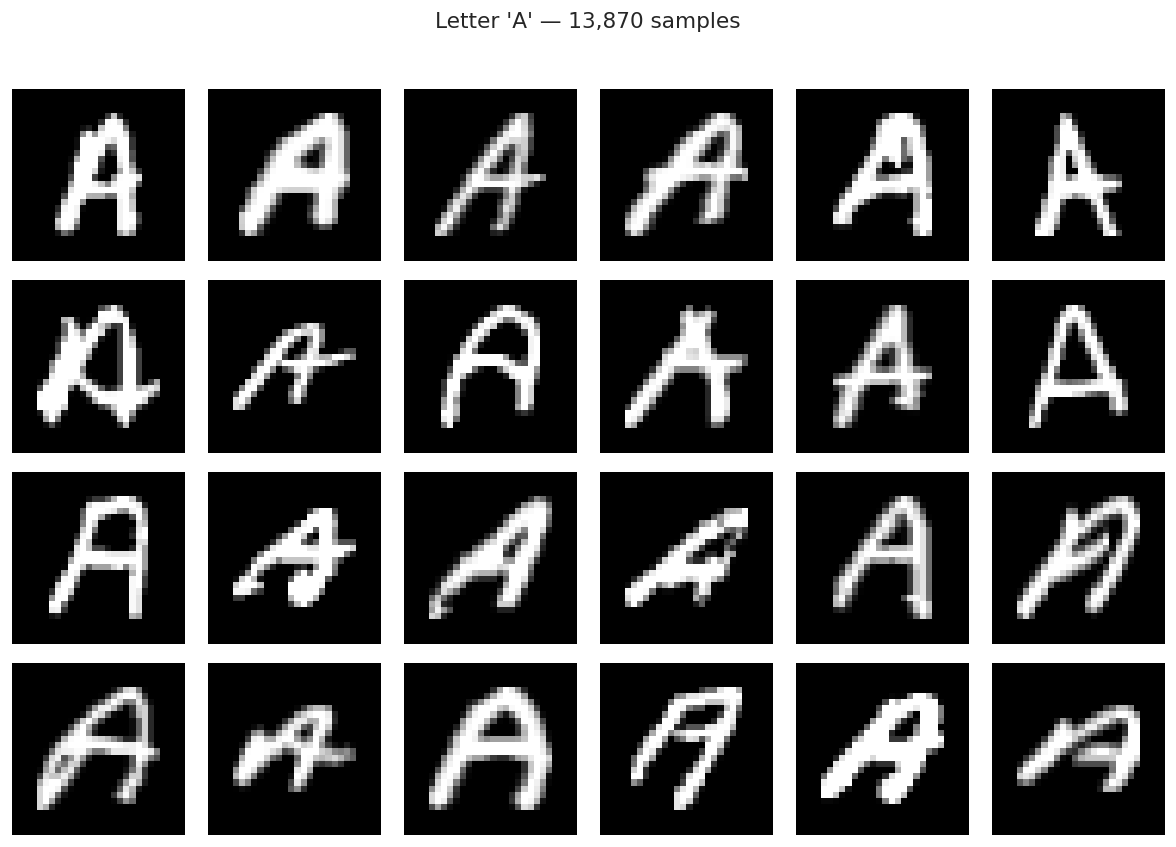

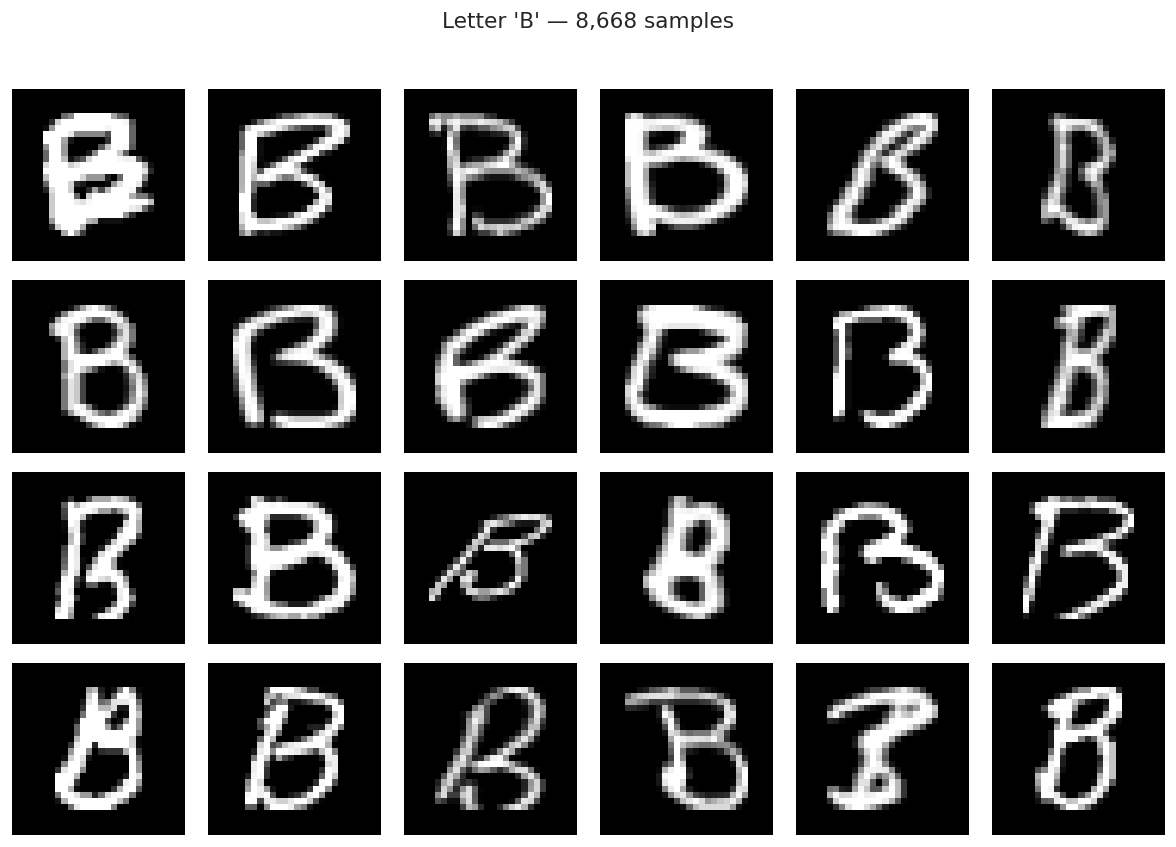

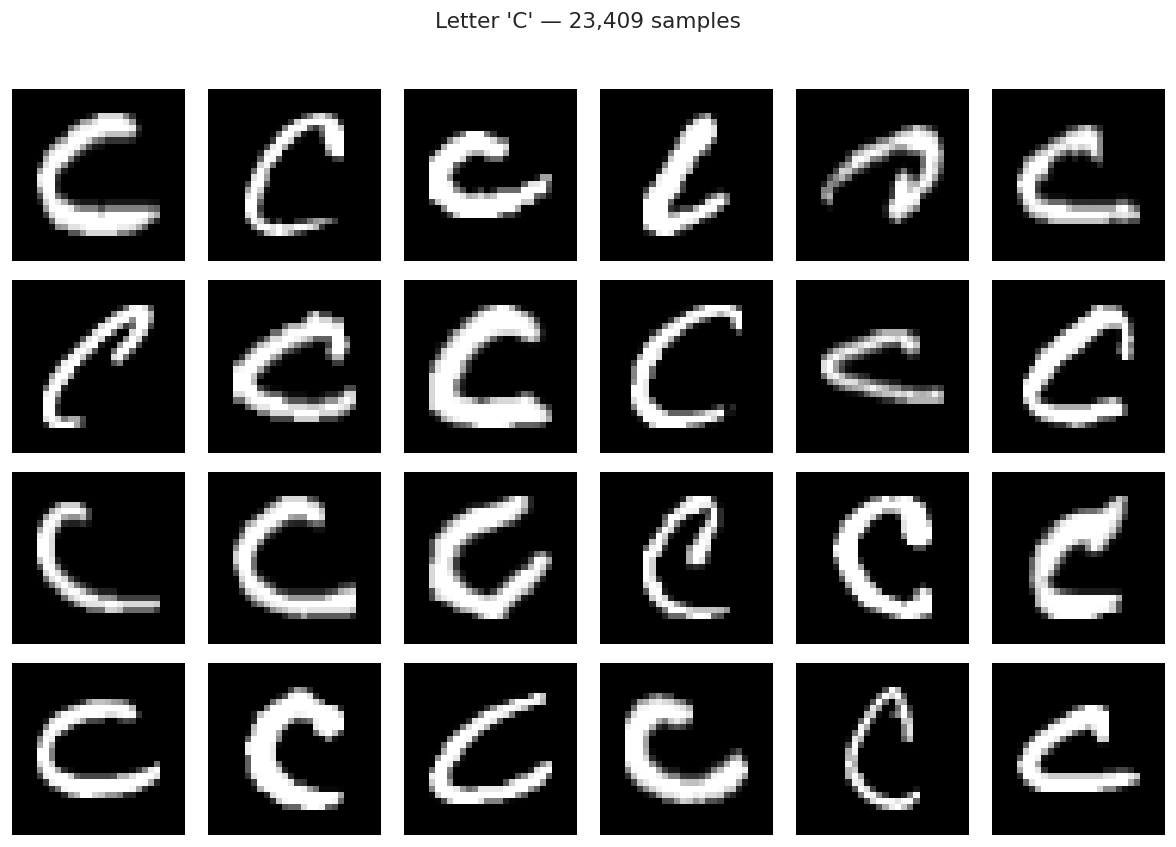

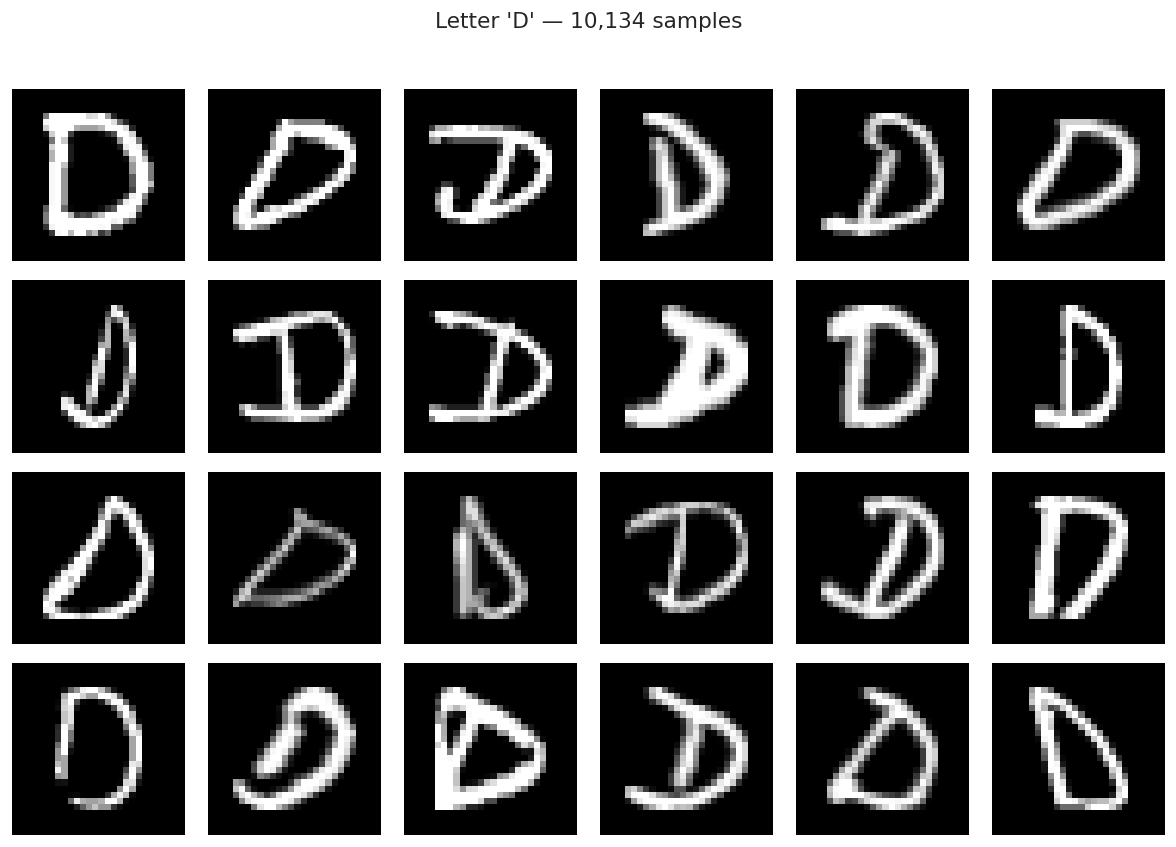

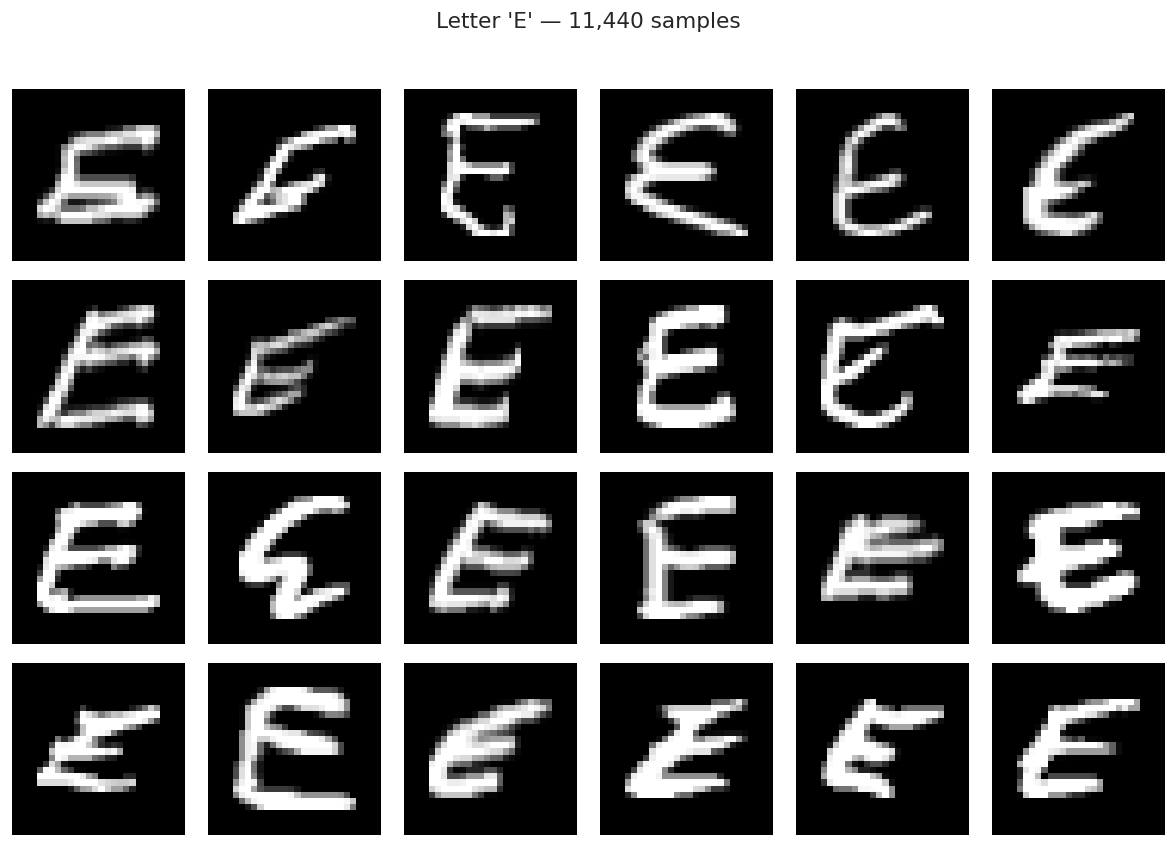

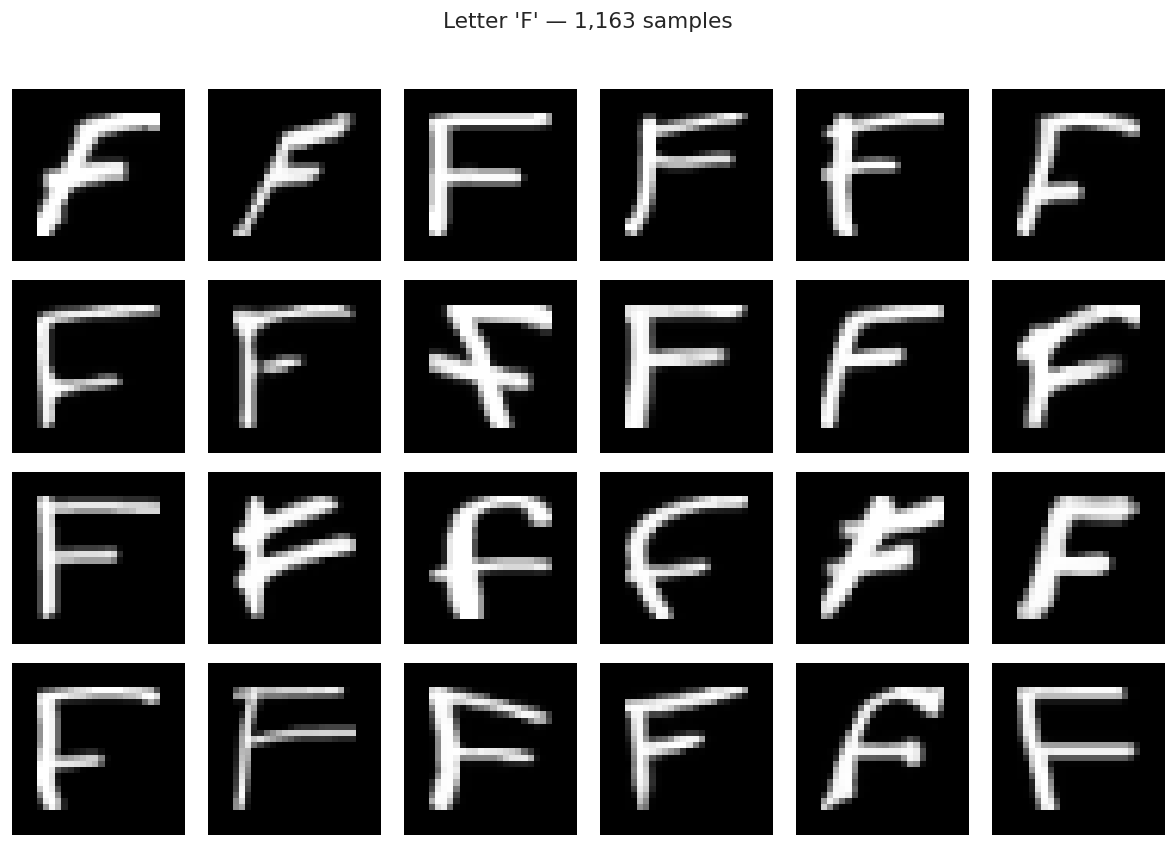

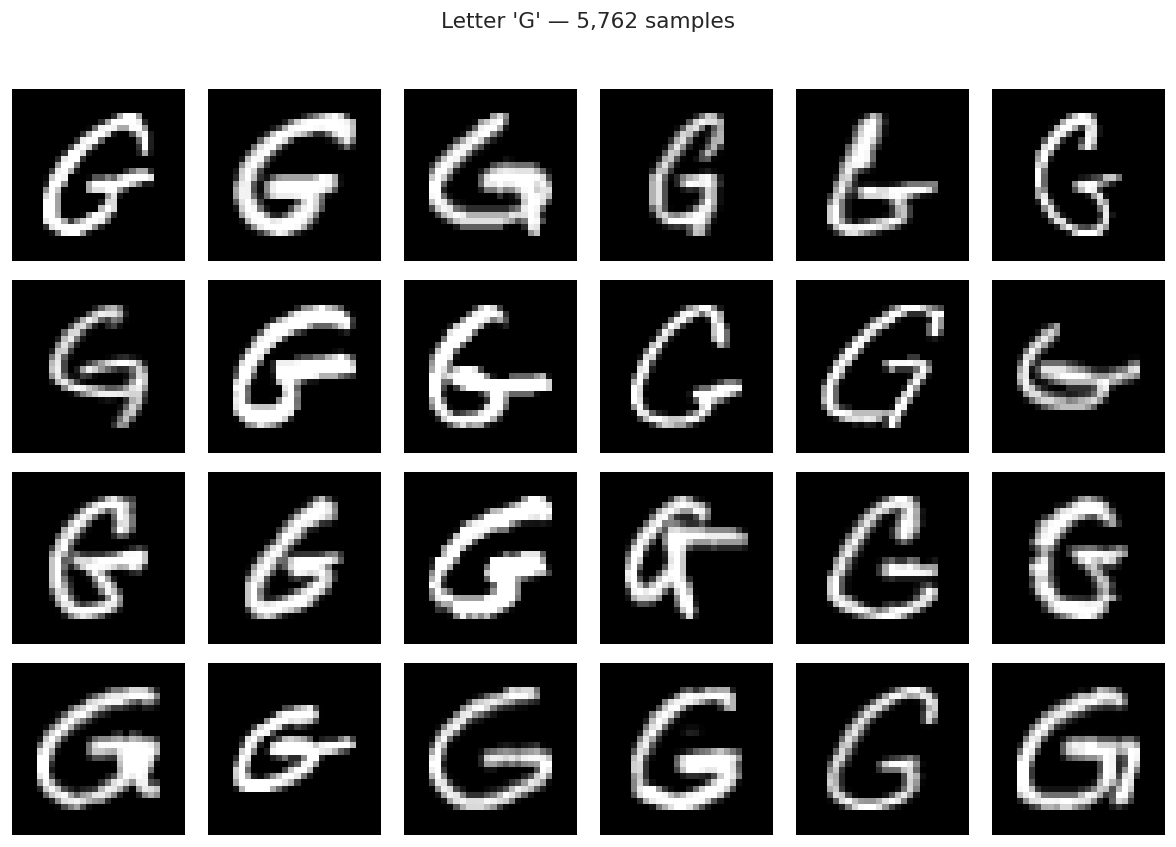

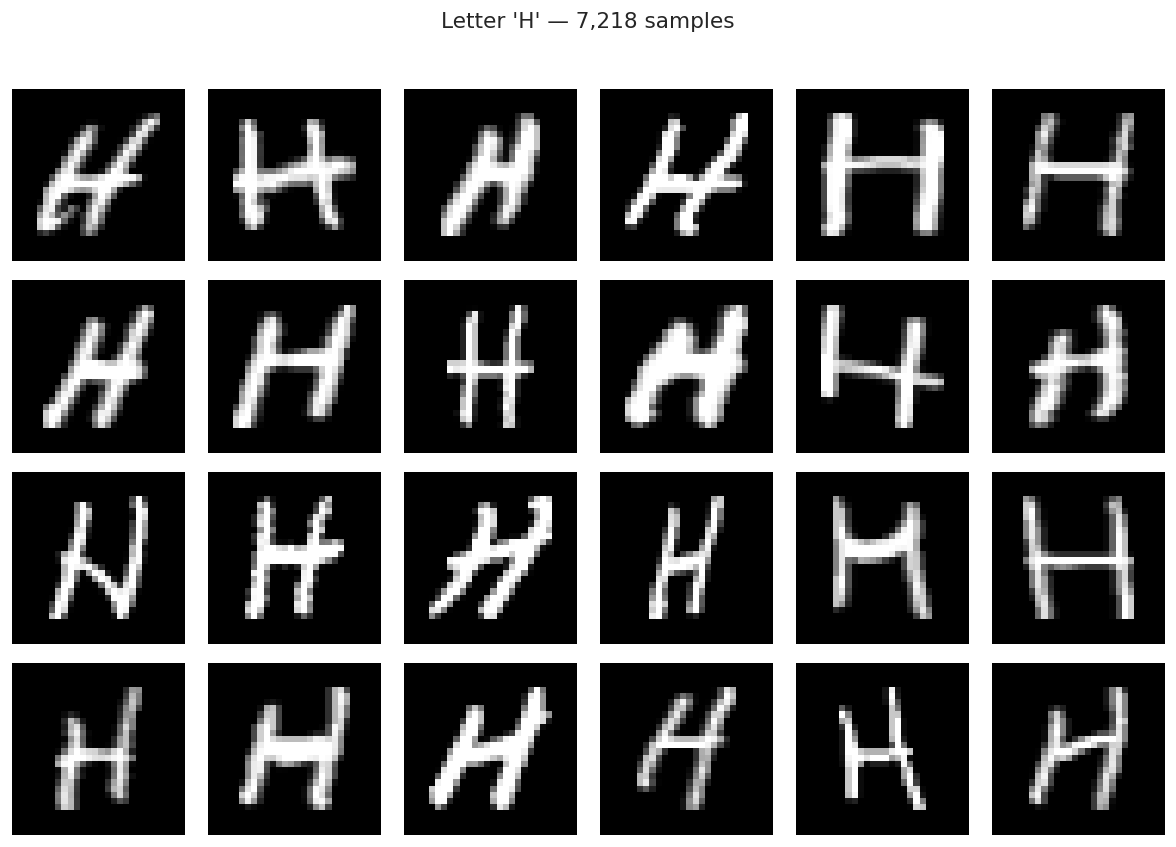

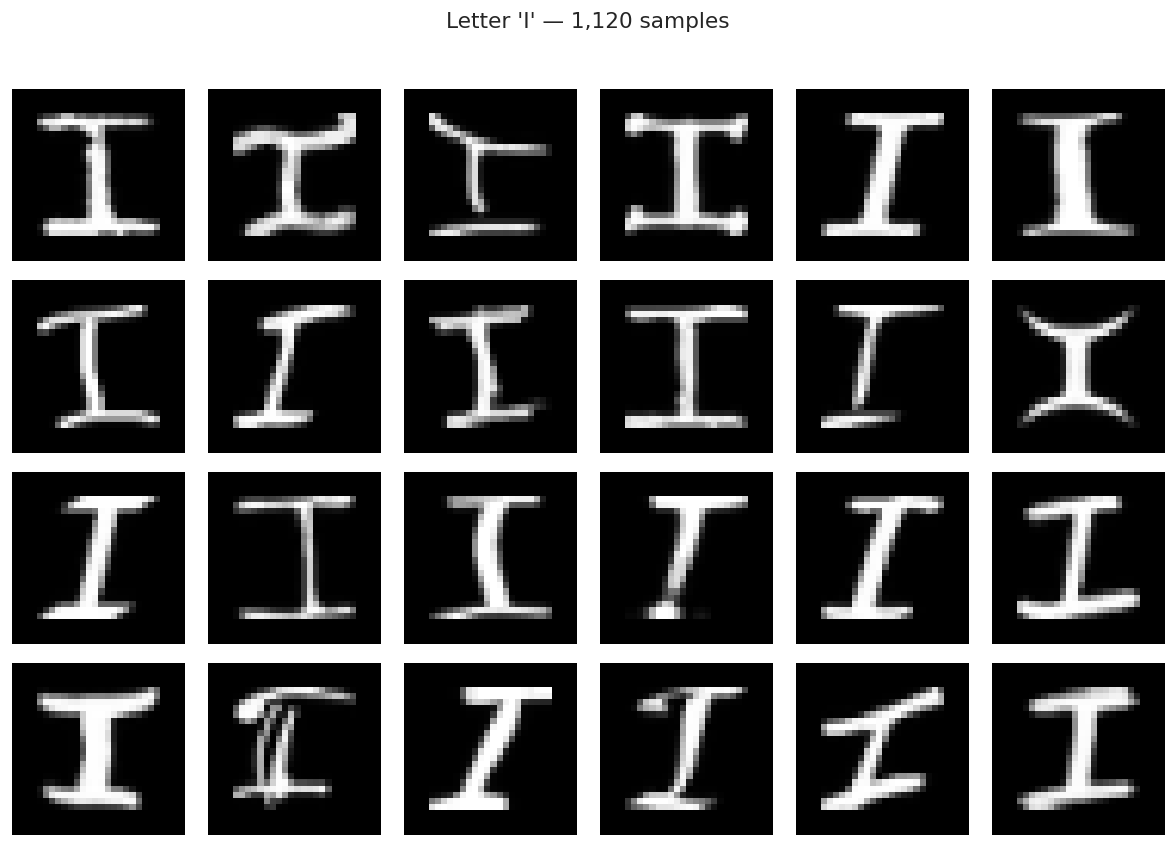

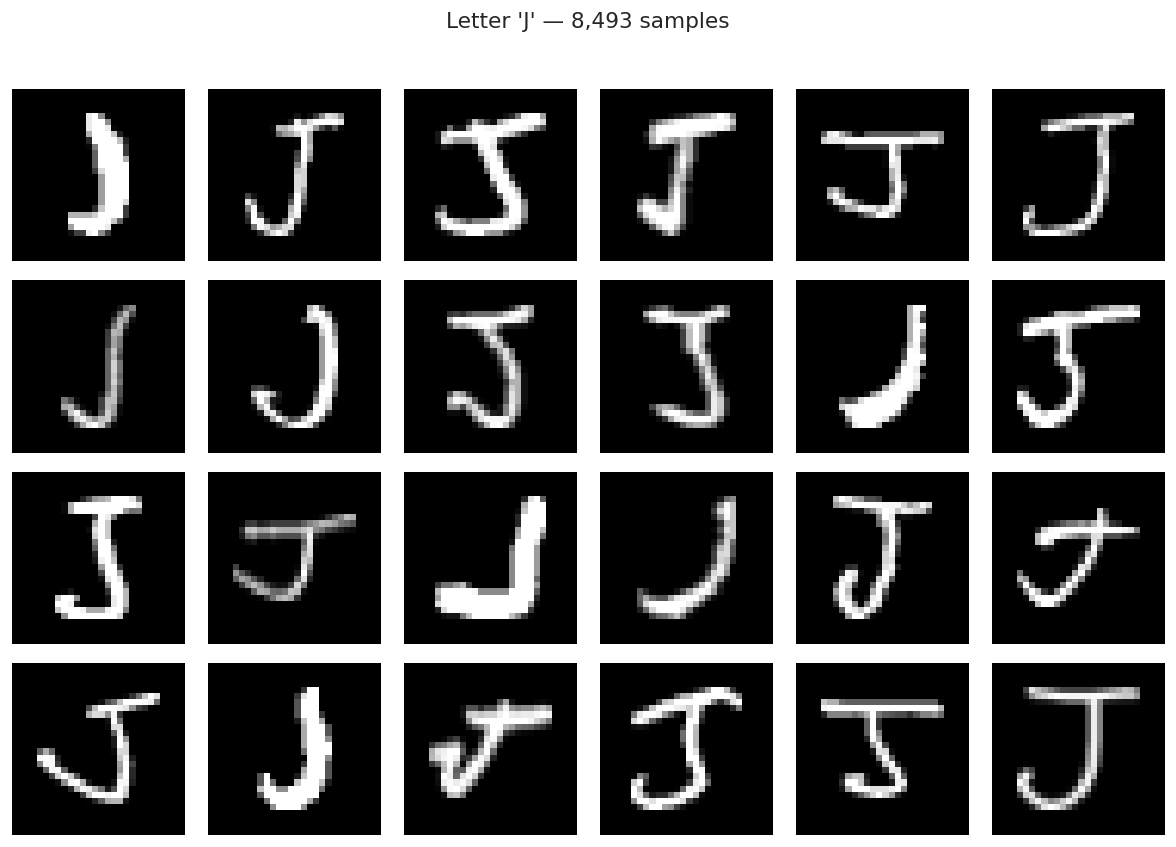

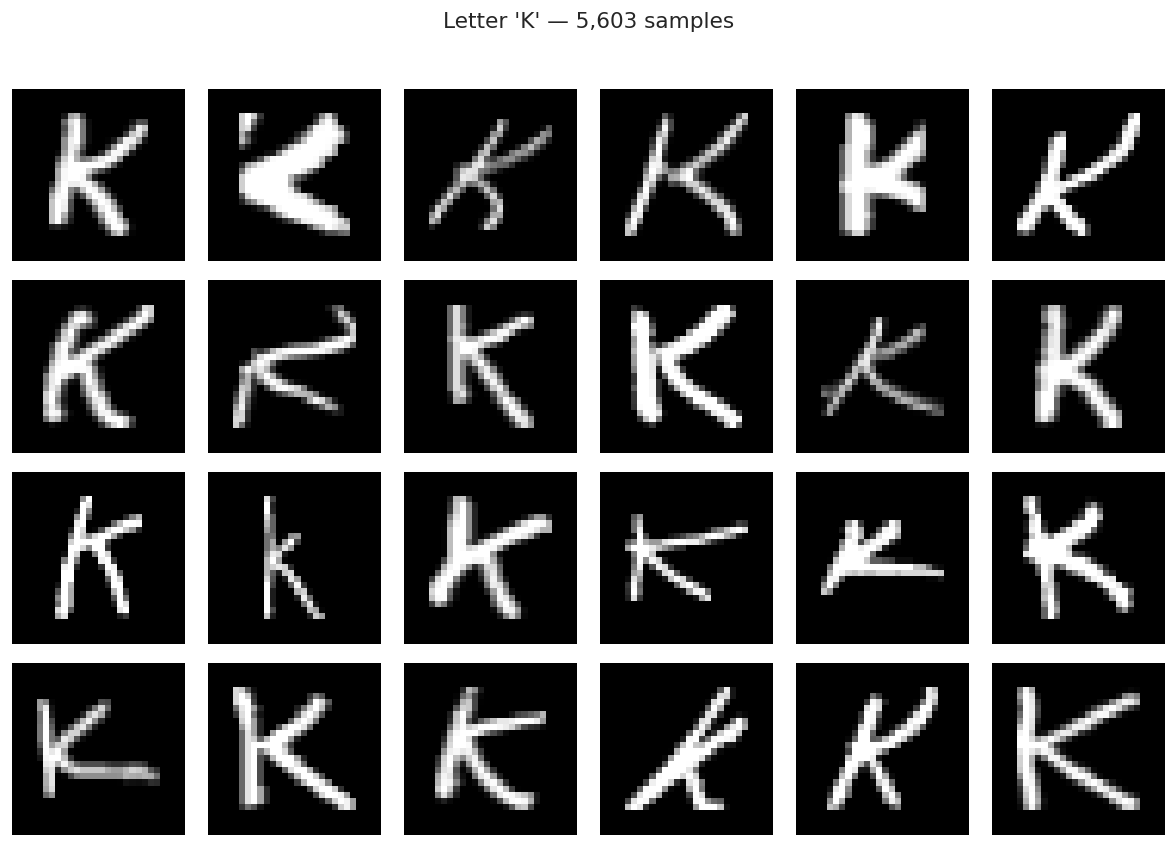

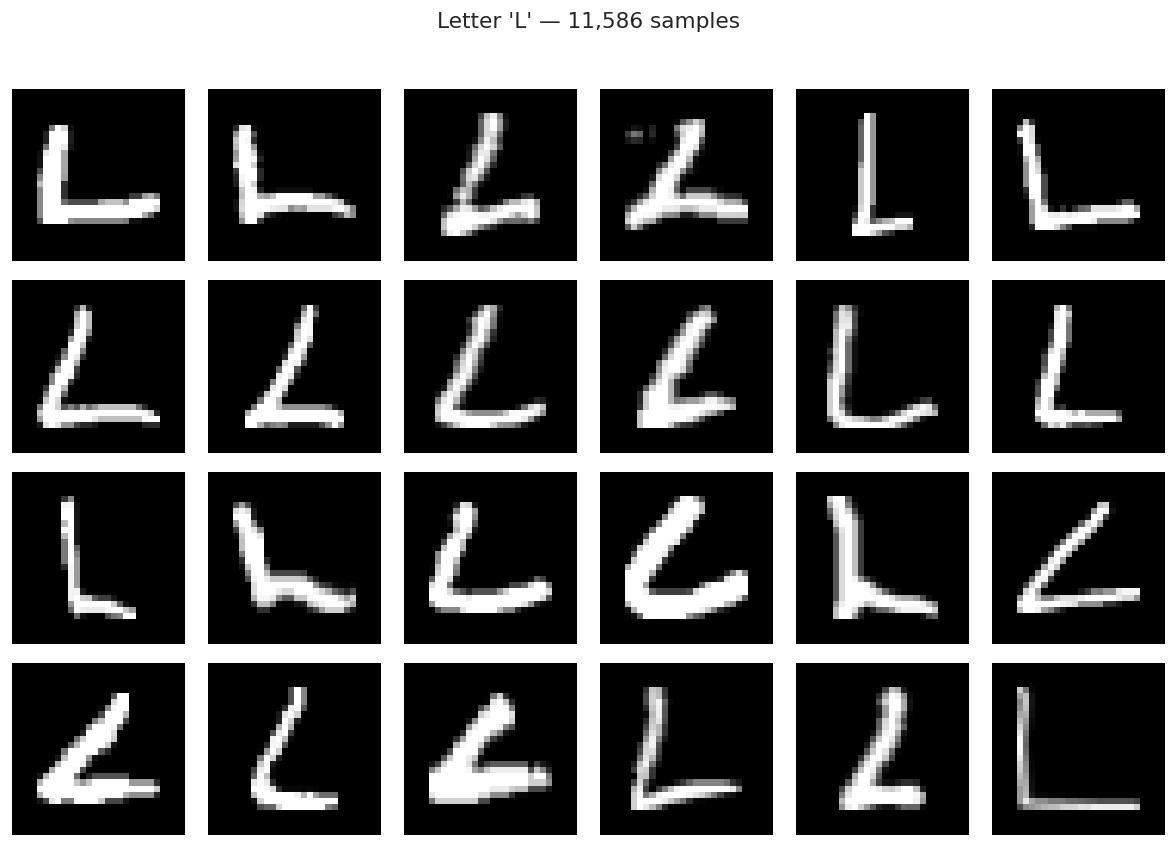

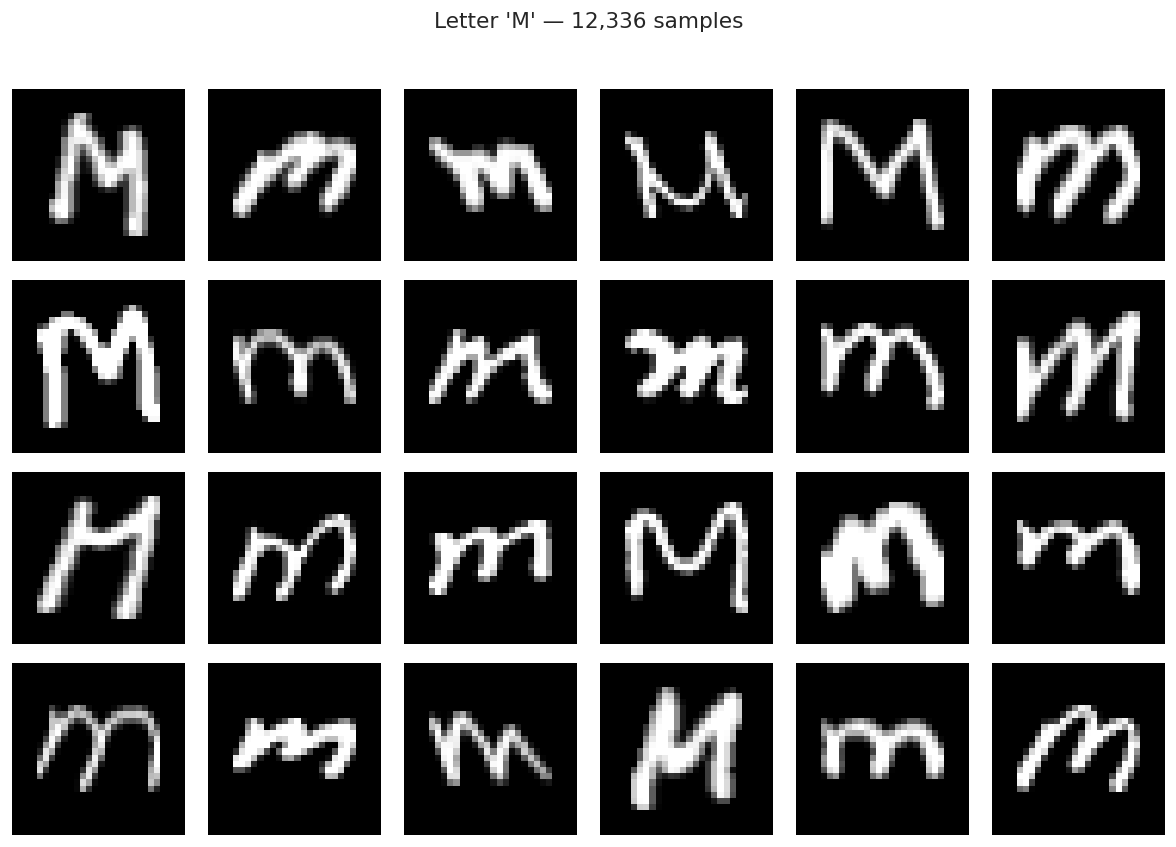

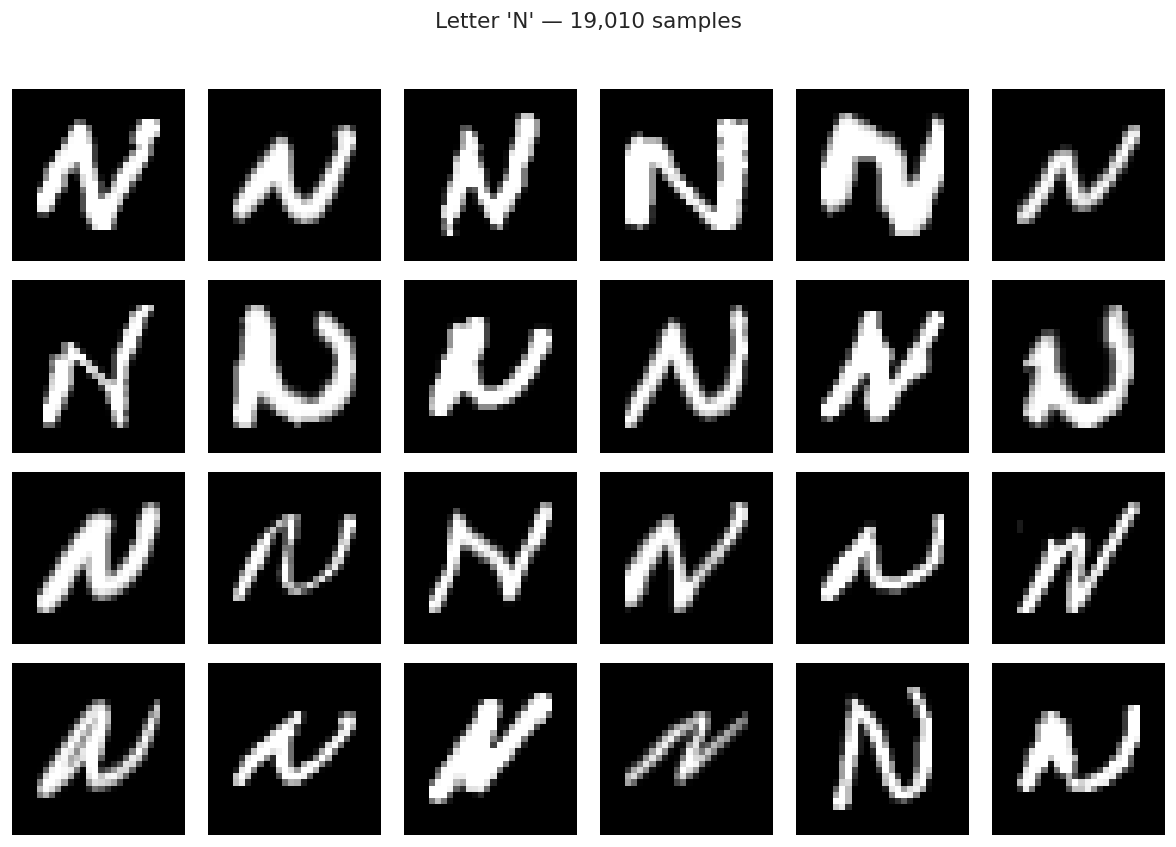

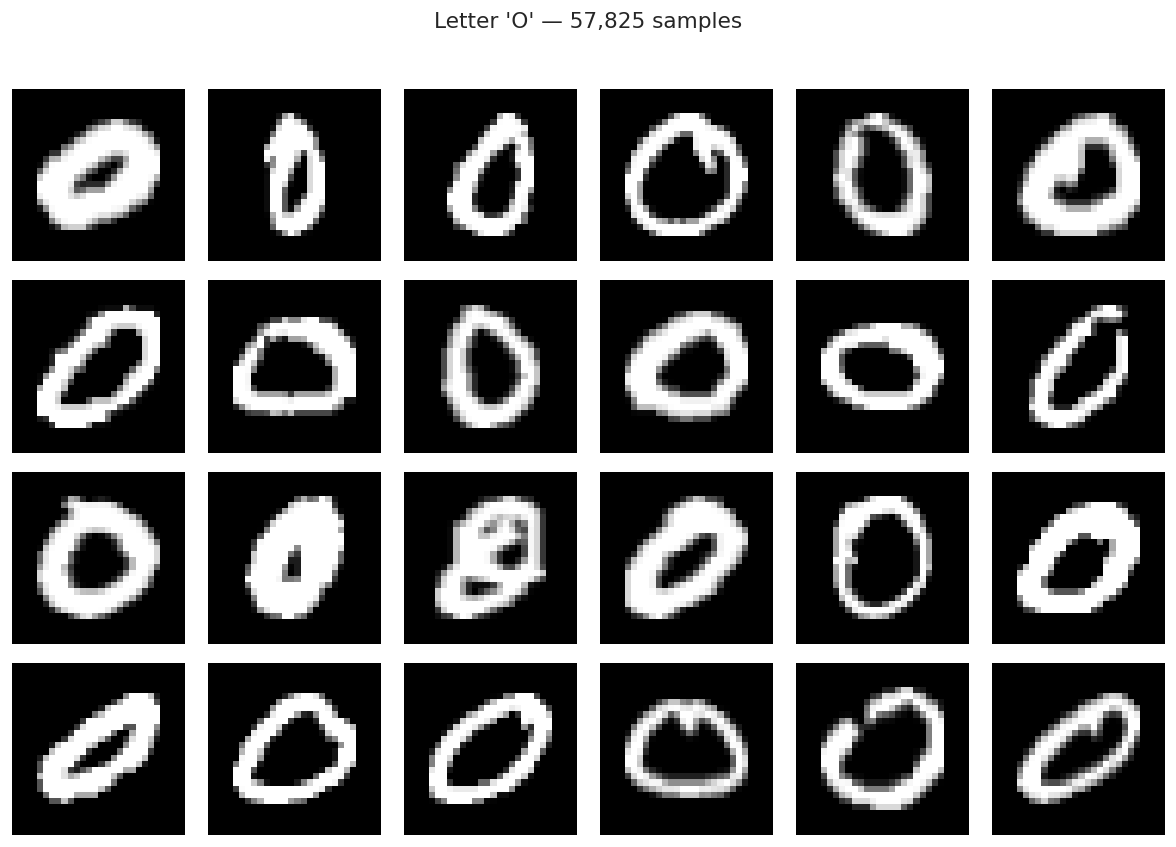

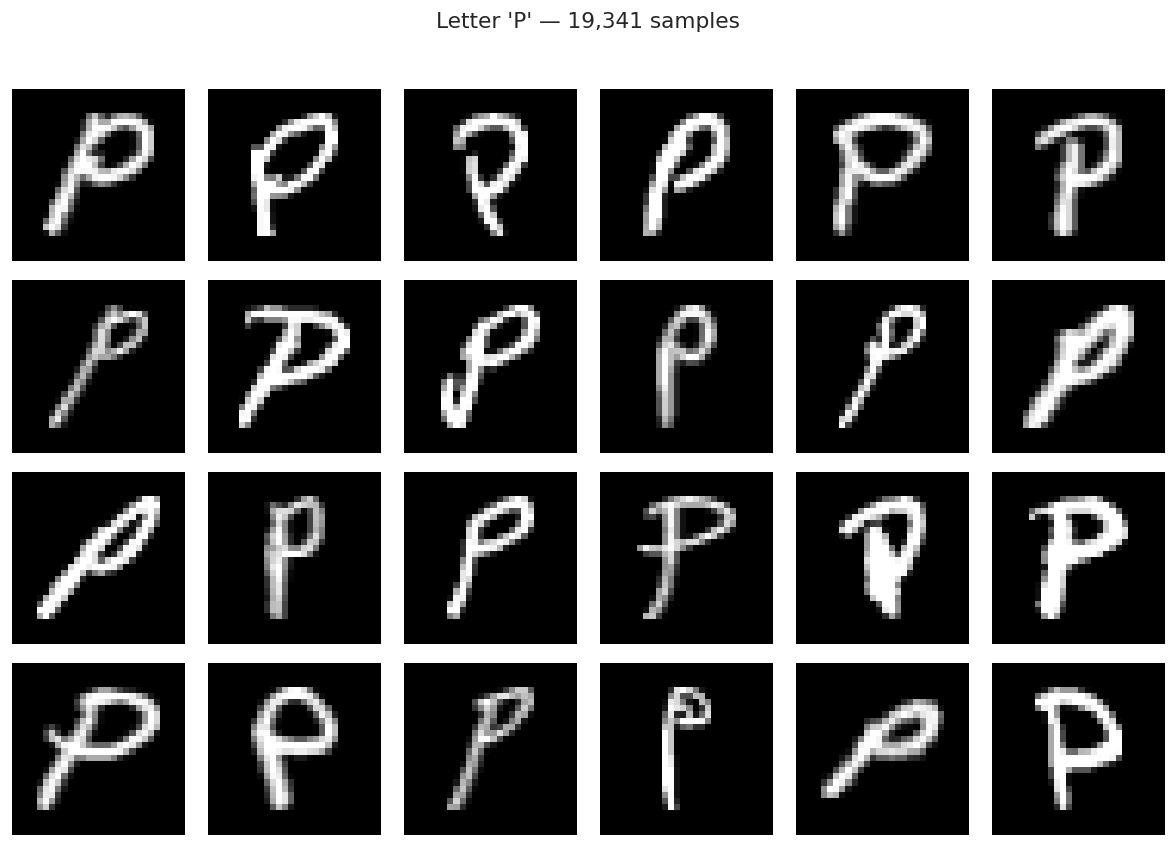

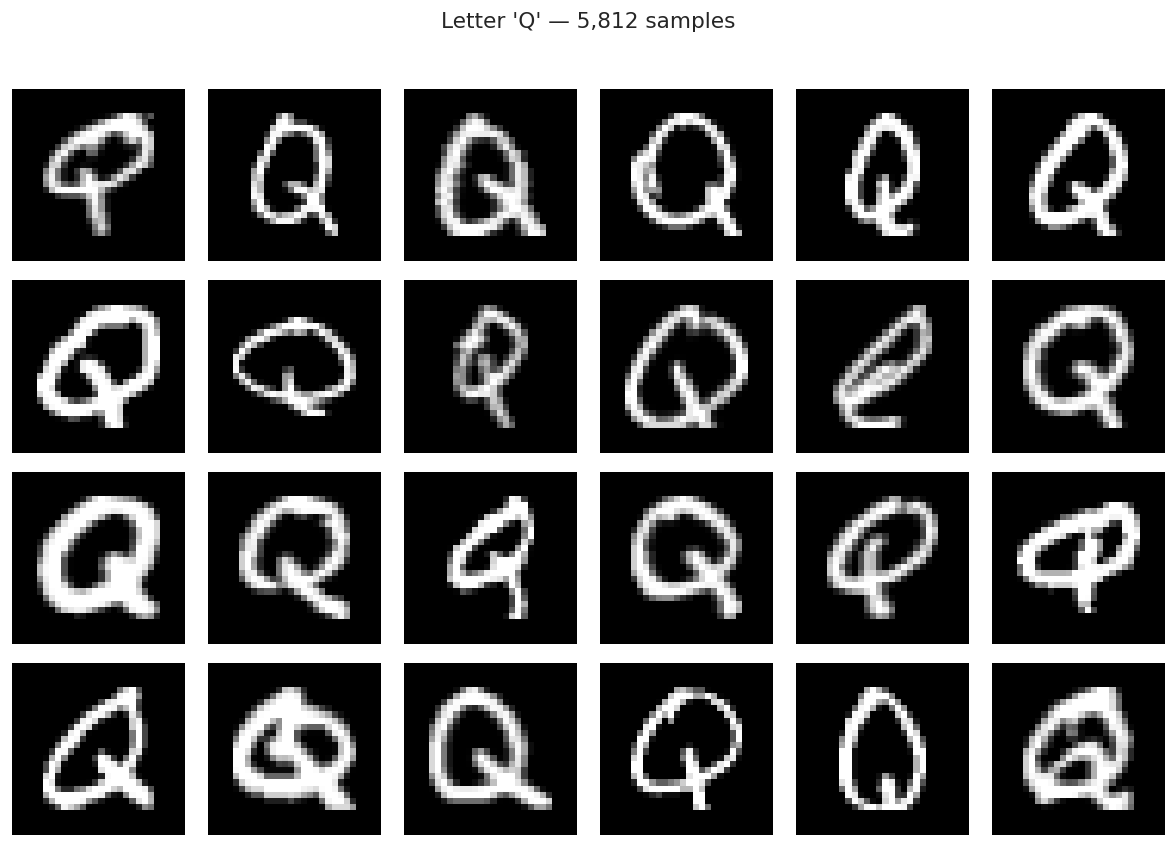

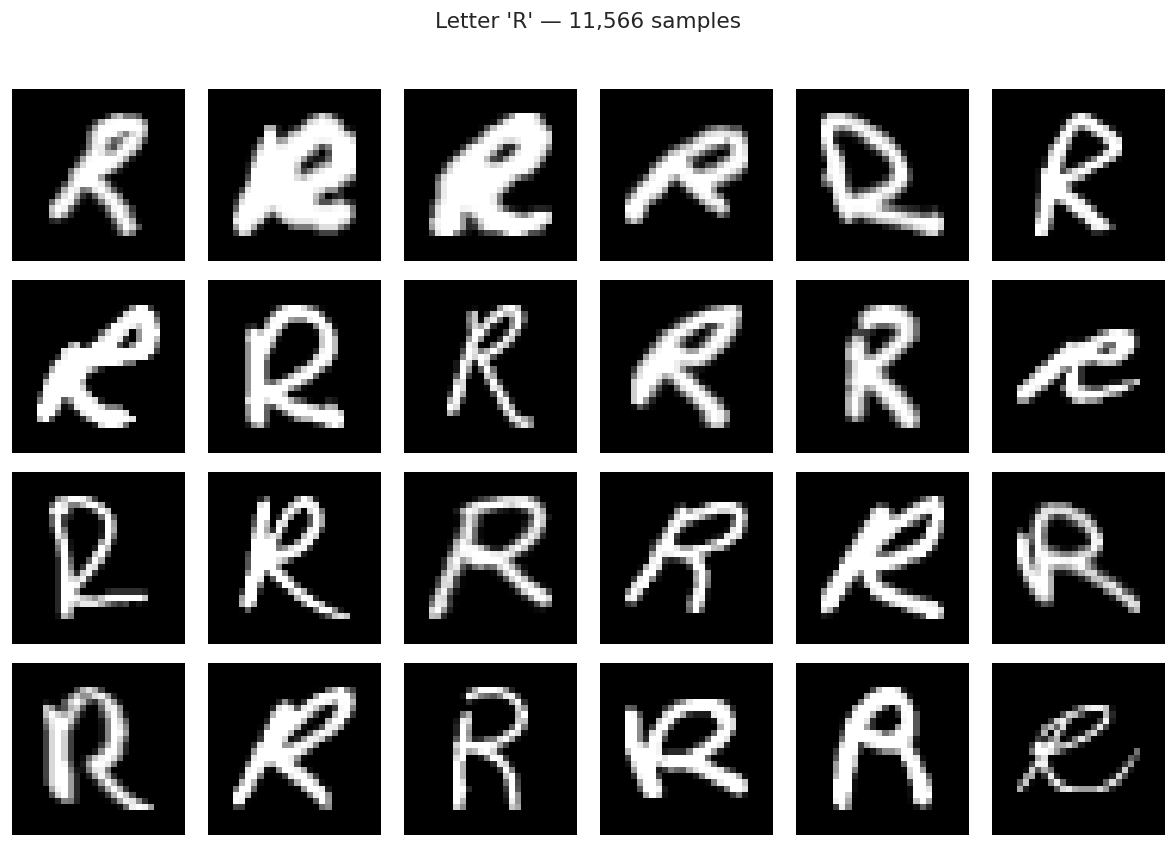

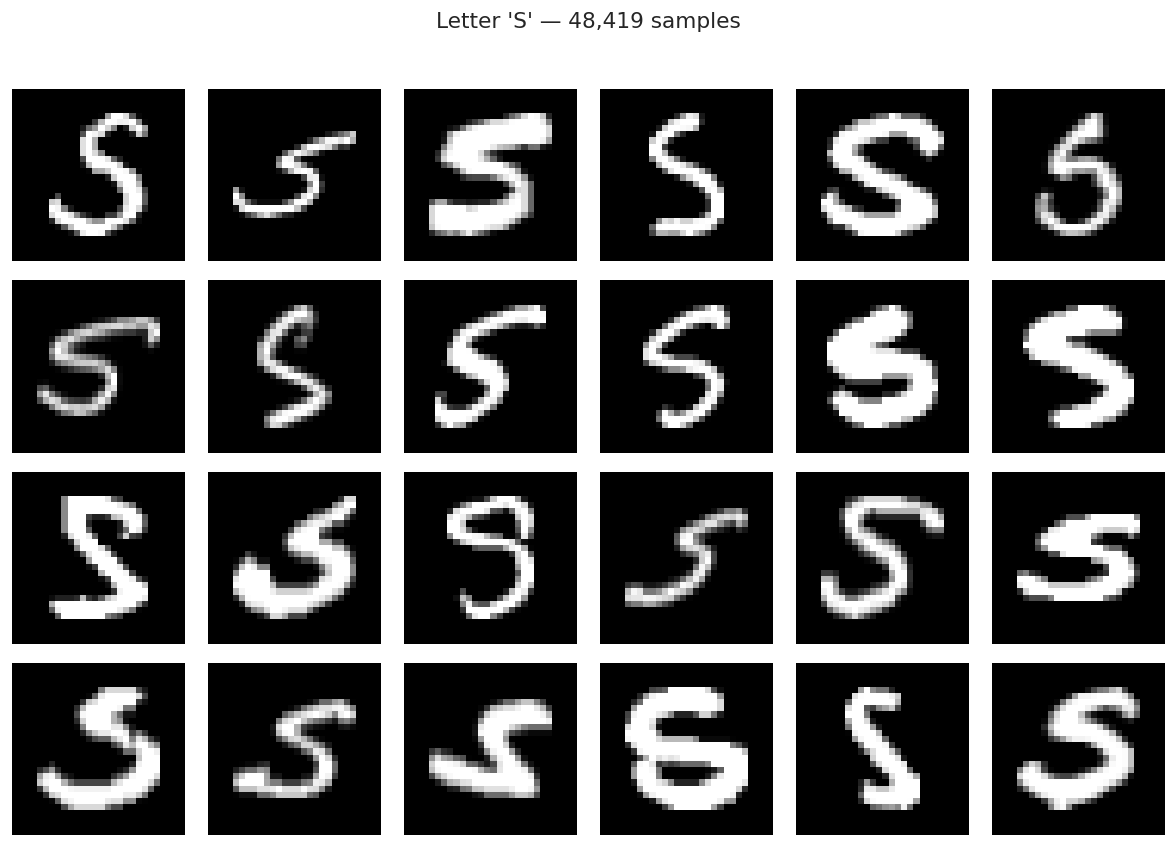

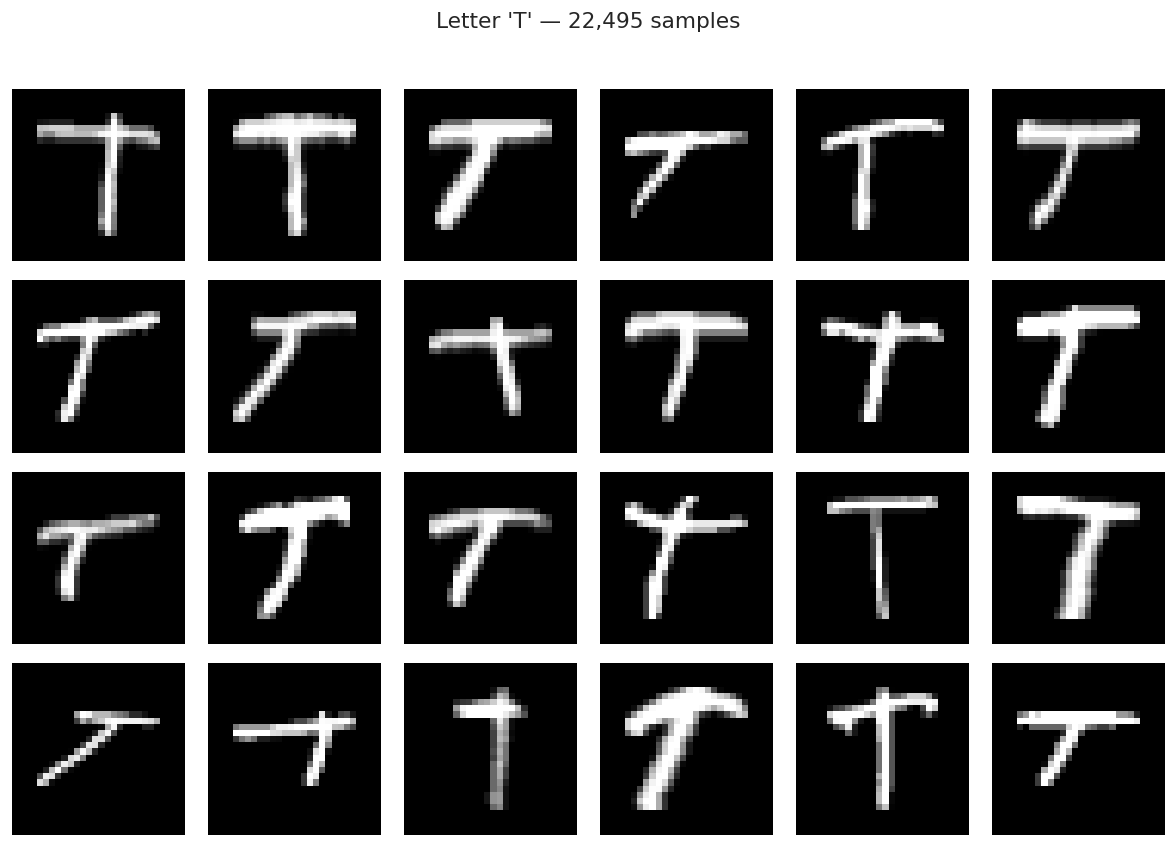

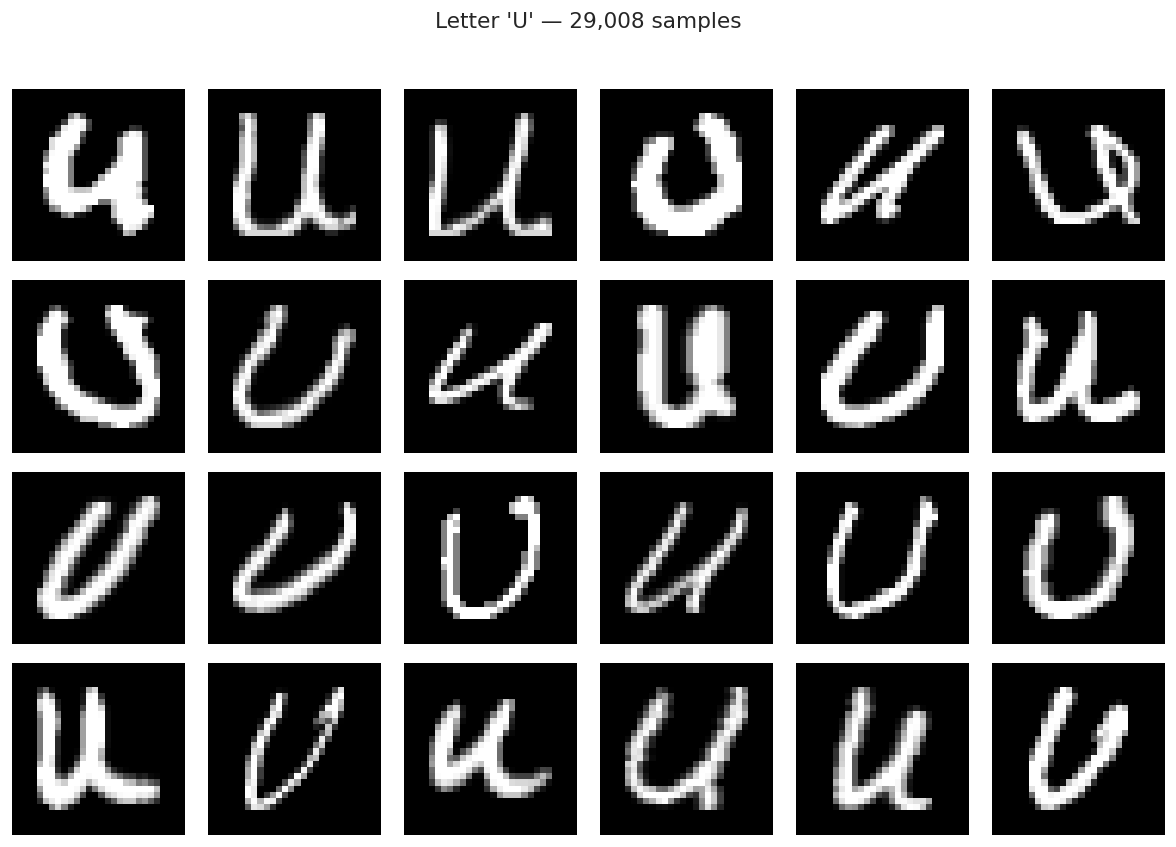

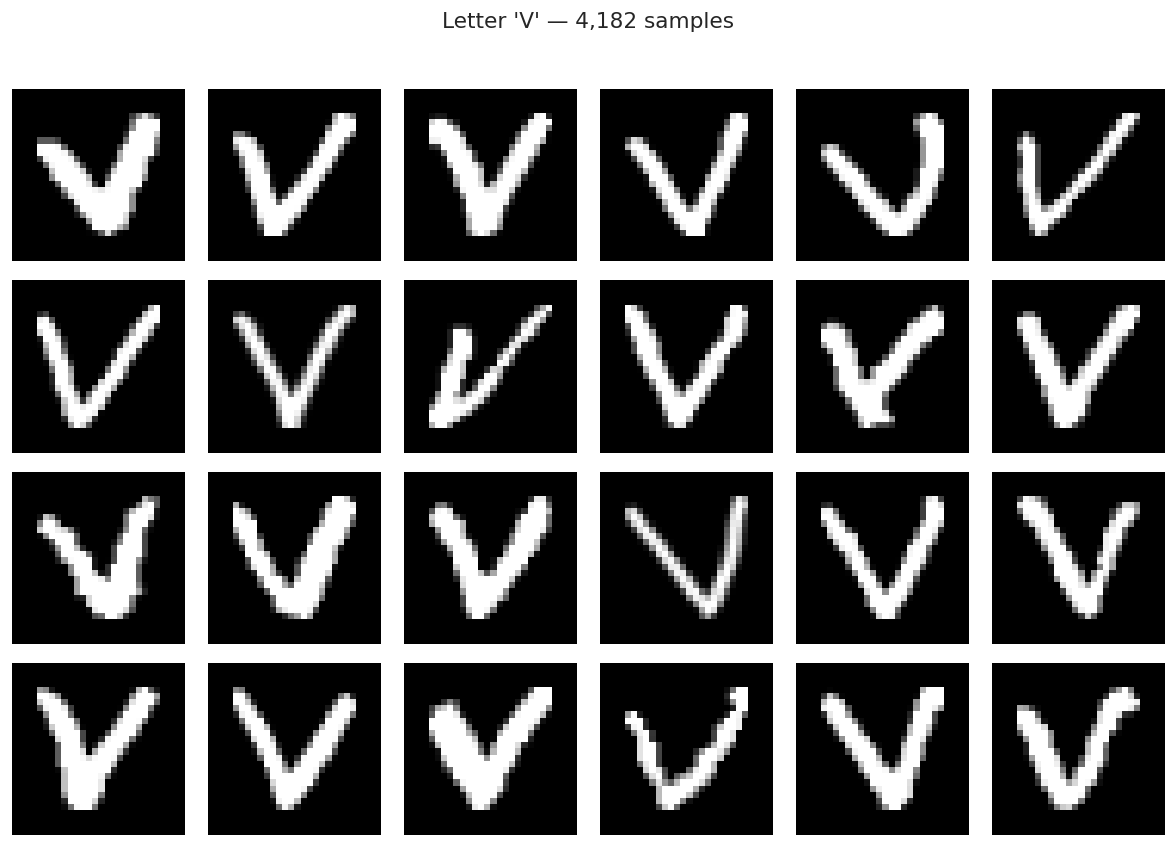

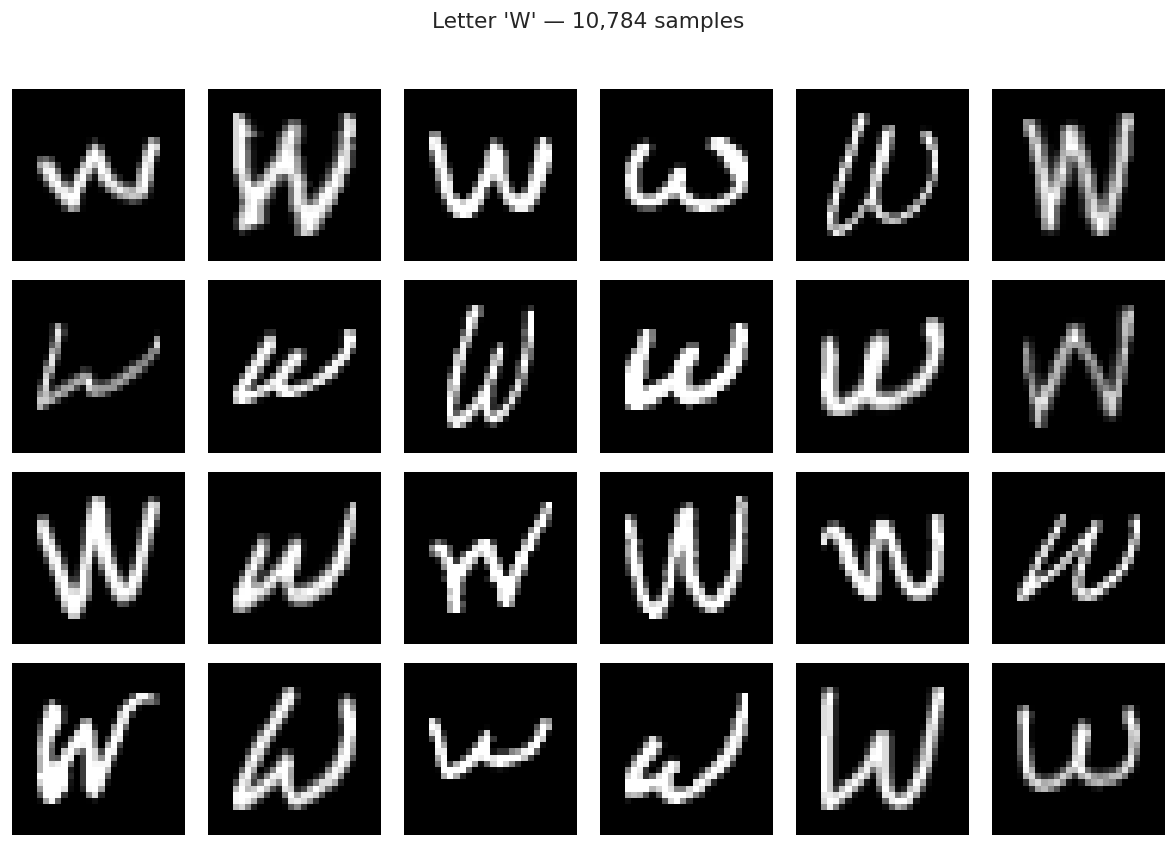

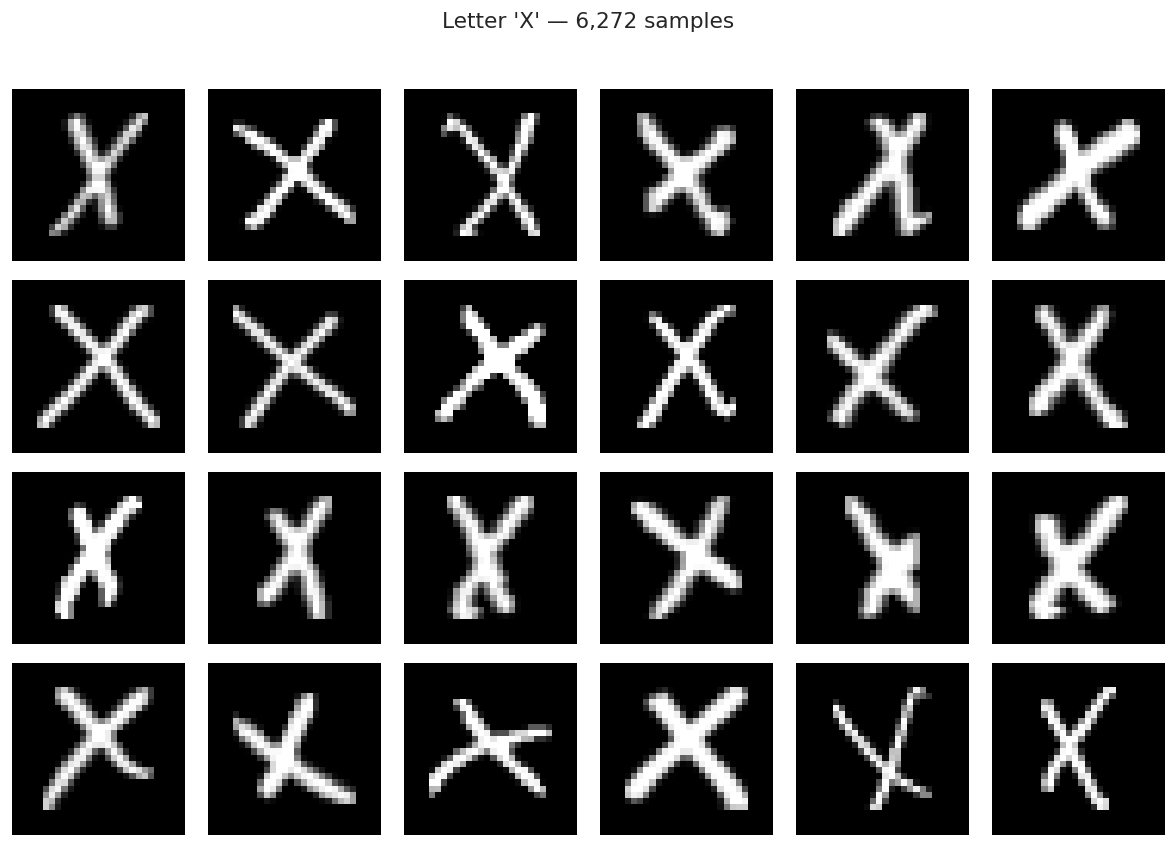

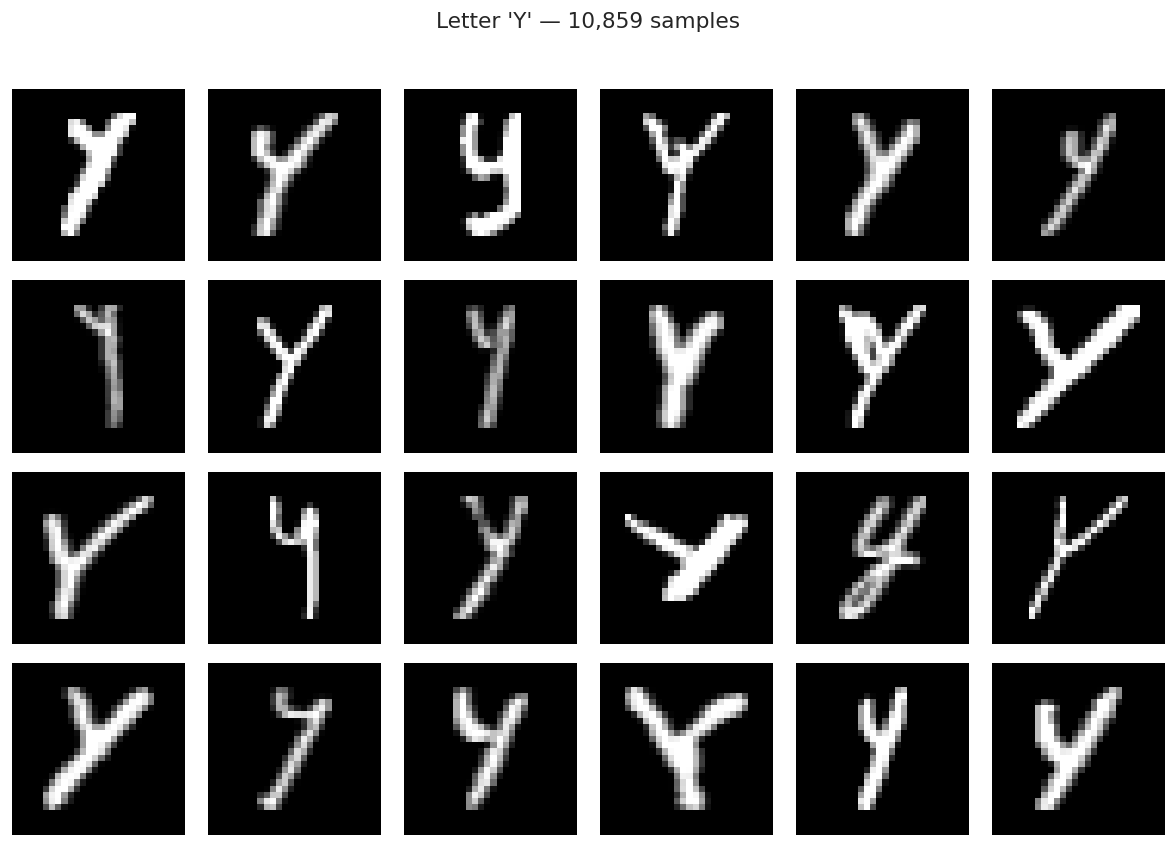

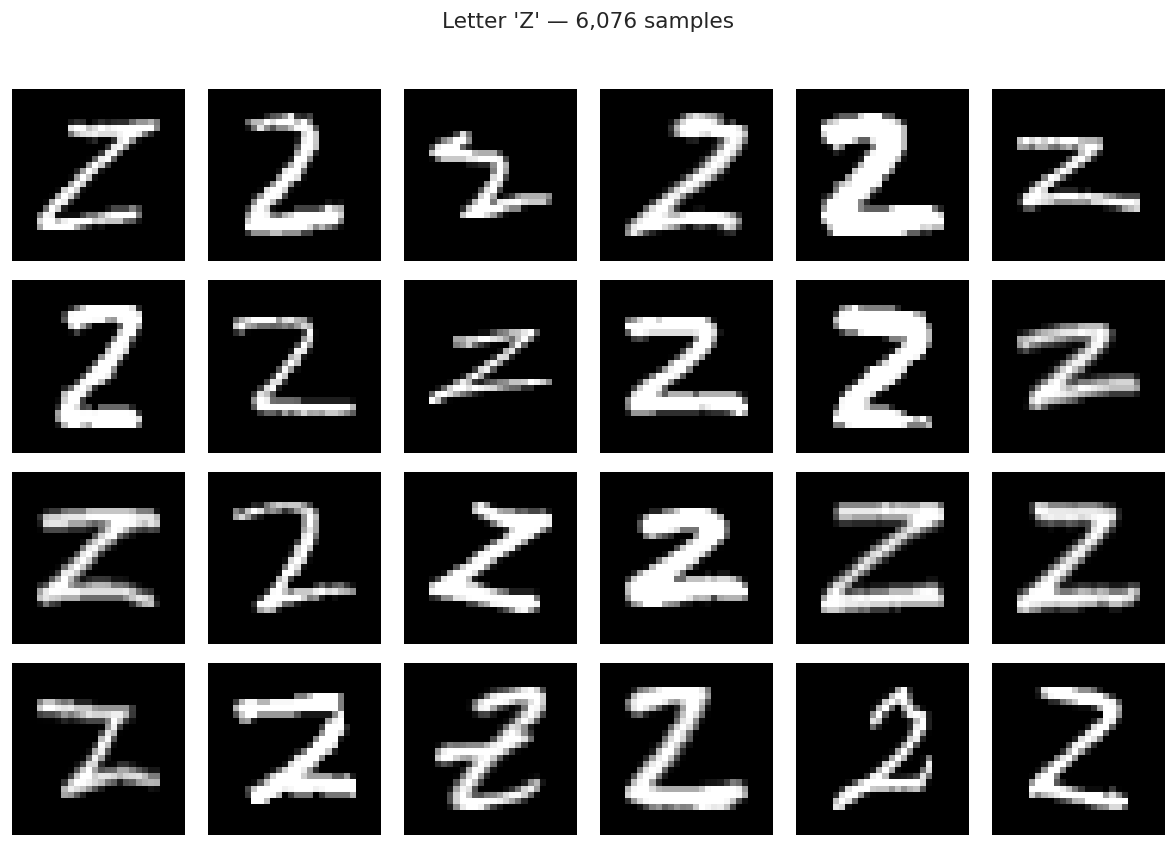

In [35]:
np.random.seed(0)   # fixed seed so the same samples appear each run

for cls in range(26):
    letter = LETTER_MAP[cls] #mapping to letters
    idx    = np.where(labels == cls)[0]  #returns [True,False, ...] and np.where returns the True ones.
    pick   = np.random.choice(idx, min(24, len(idx)), replace=False)

    fig, axes = plt.subplots(4, 6, figsize=(10, 7)) #4-row x 6-column grid = 24 slots
    fig.suptitle(f"Letter '{letter}' — {len(idx):,} samples",
                 fontsize=13, y=1.01)

    for ax, i in zip(axes.flatten(), pick): #fill each slot with a picked image
        ax.imshow(images[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

    for ax in axes.flatten()[len(pick):]:#hide any unused subplot slots
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

##Class Distrubution

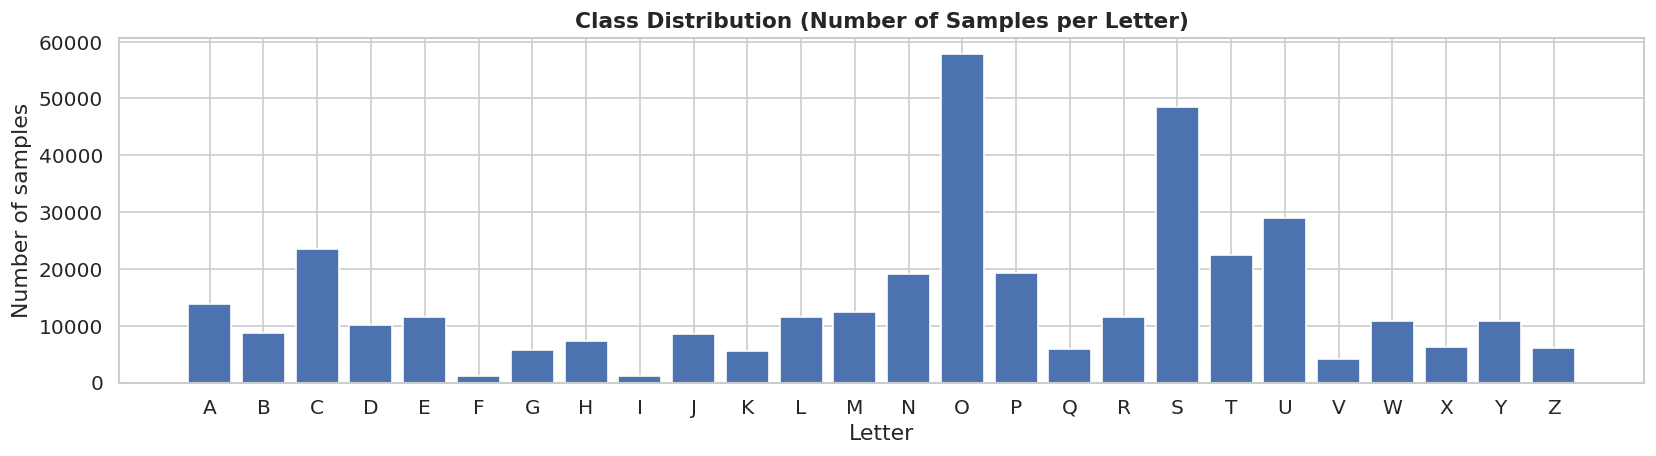

In [71]:
# Count how many samples per class
counts = np.bincount(labels, minlength=26)

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(letters, counts, edgecolor='white')

ax.set_xlabel('Letter')
ax.set_ylabel('Number of samples')
ax.set_title('Class Distribution (Number of Samples per Letter)')

plt.tight_layout()
plt.show()

- Original dataset is imbalanced.

## Confusable pairs

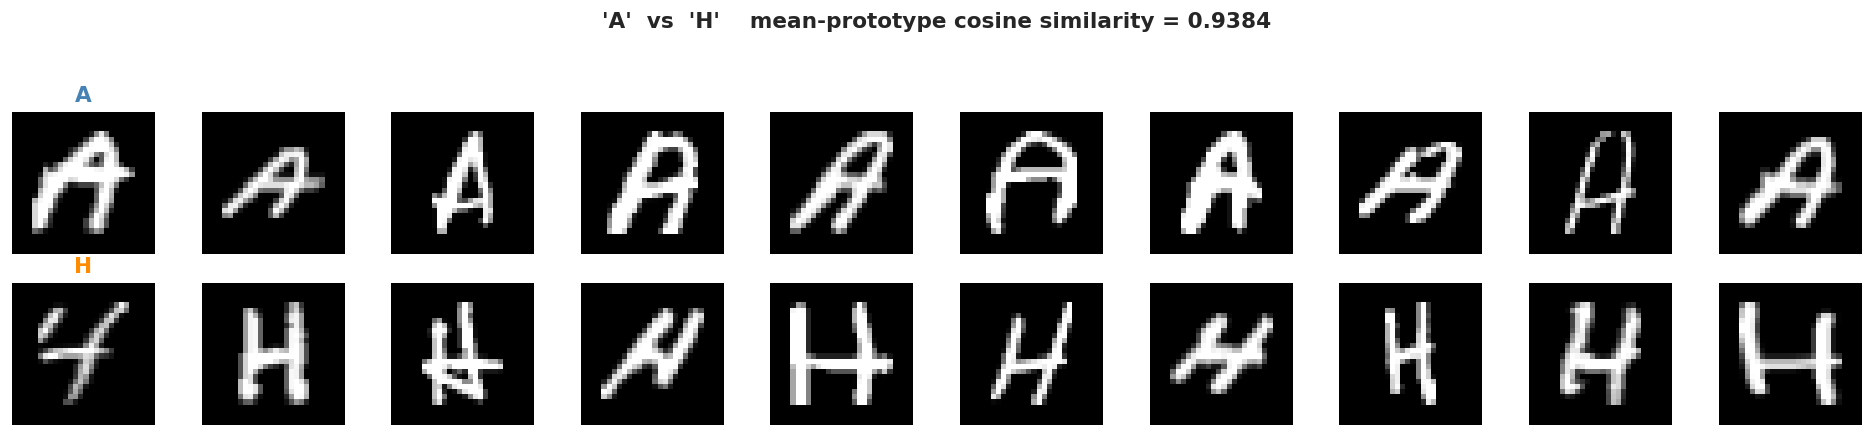

  A <-> H   sim=0.9384   HIGH


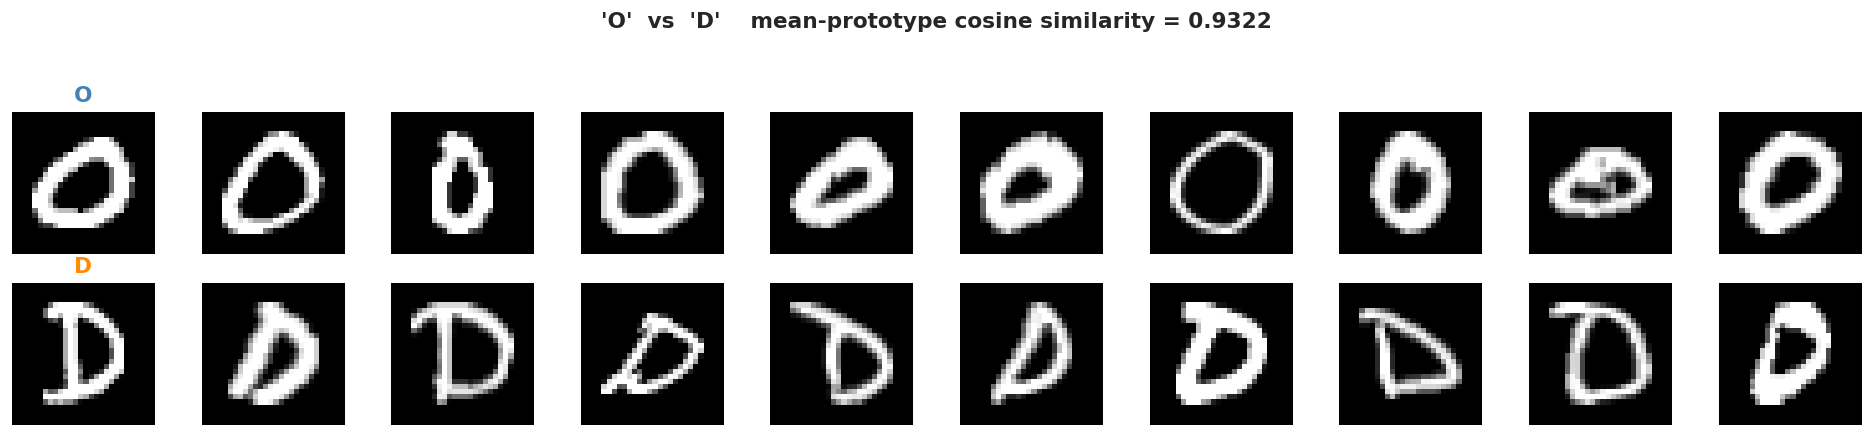

  O <-> D   sim=0.9322   HIGH


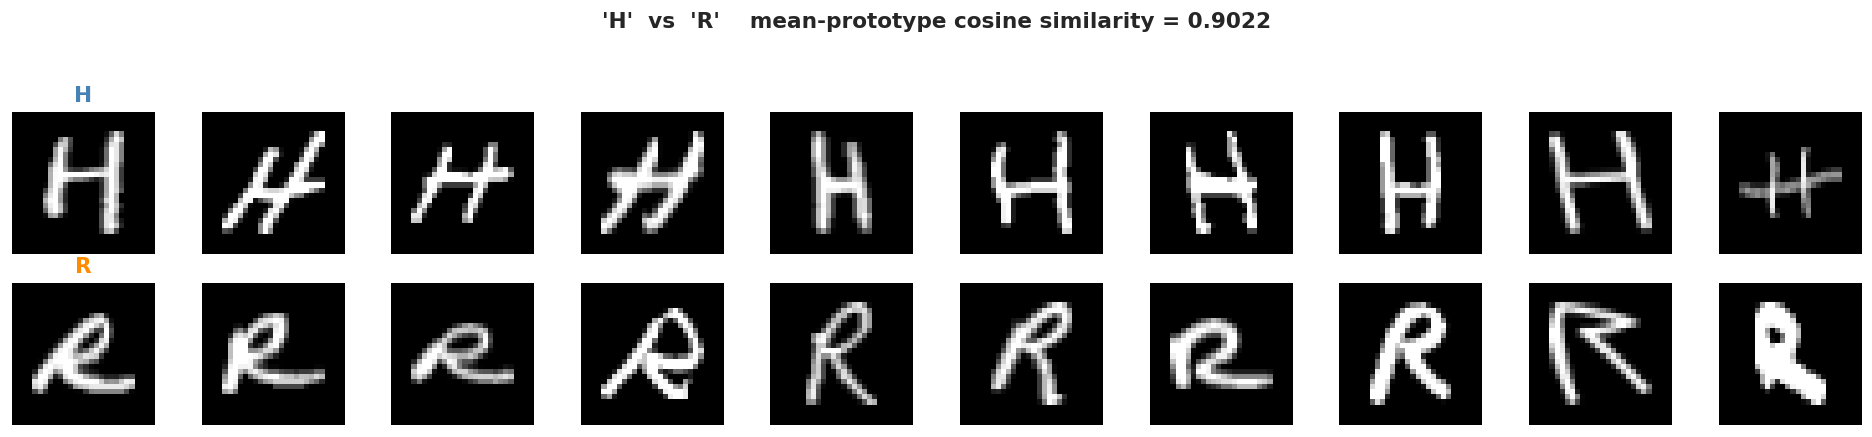

  H <-> R   sim=0.9022   MED


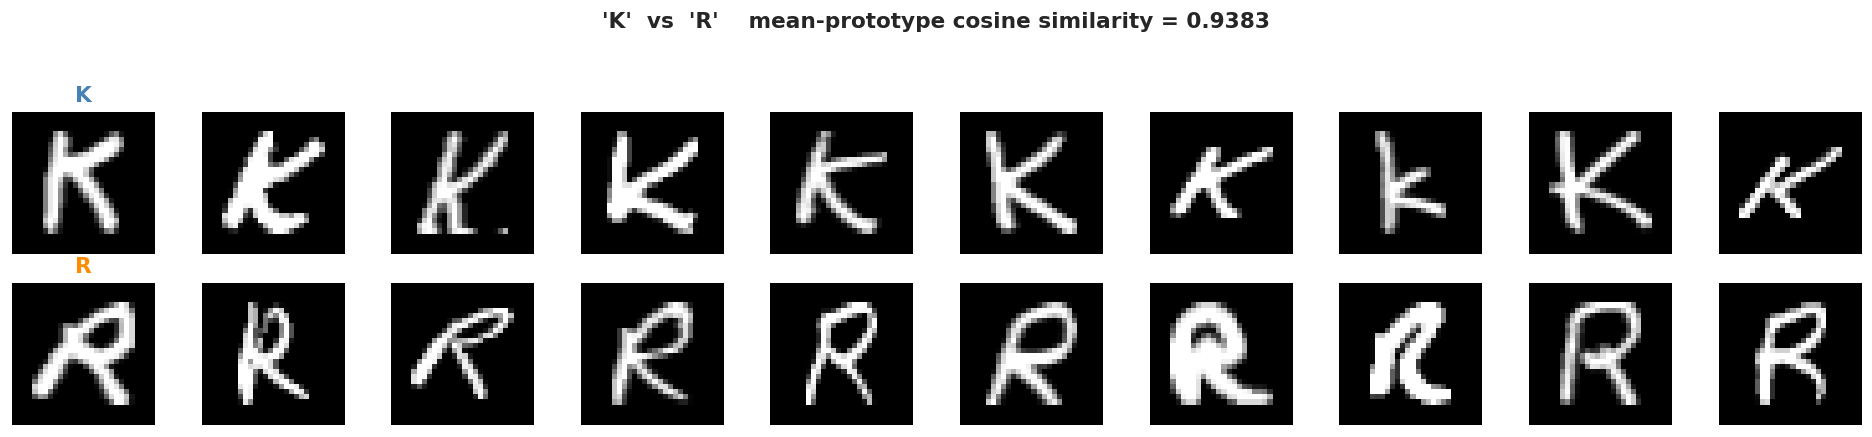

  K <-> R   sim=0.9383   HIGH


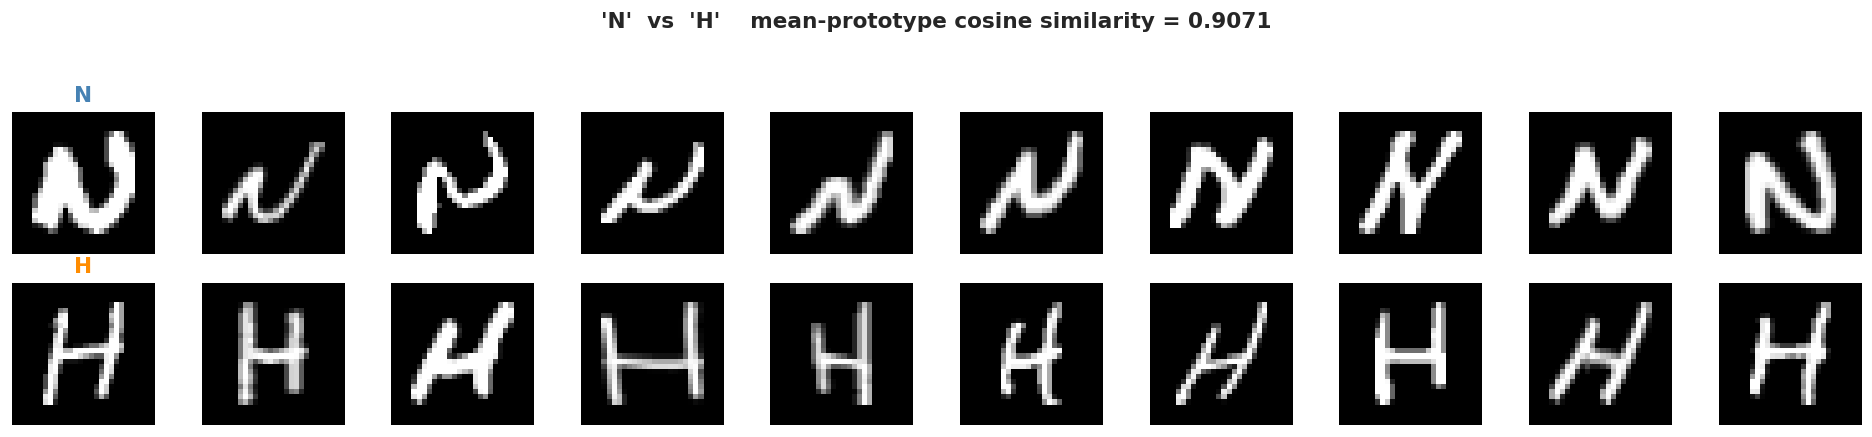

  N <-> H   sim=0.9071   MED


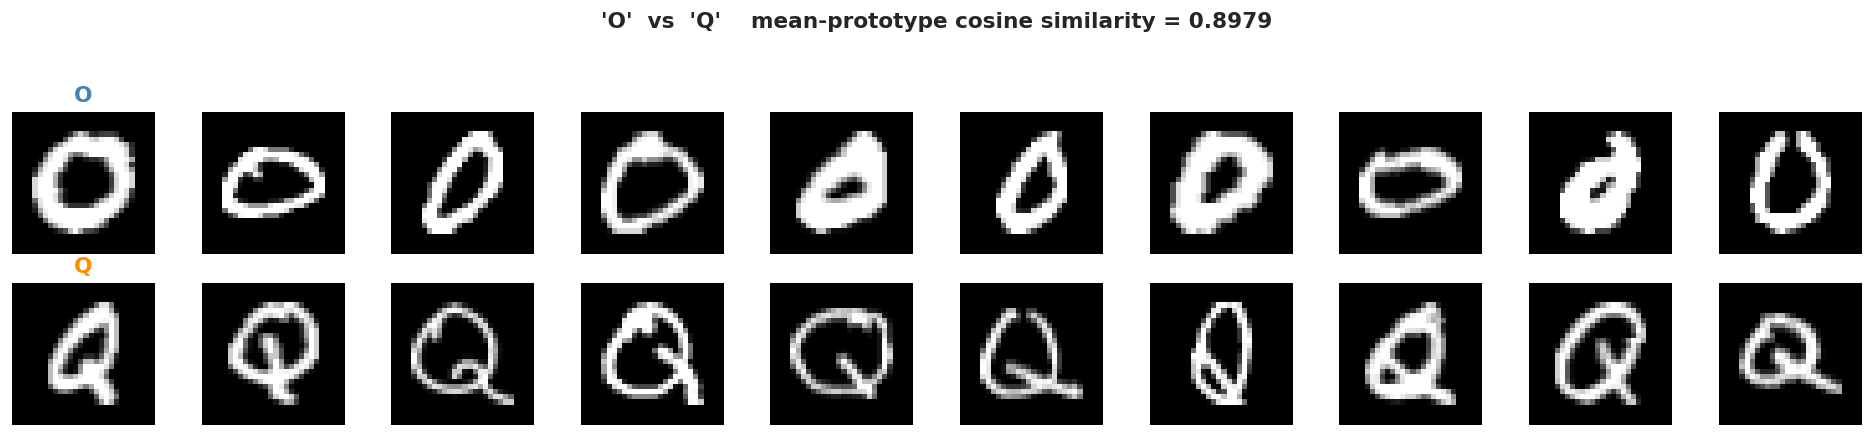

  O <-> Q   sim=0.8979   MED


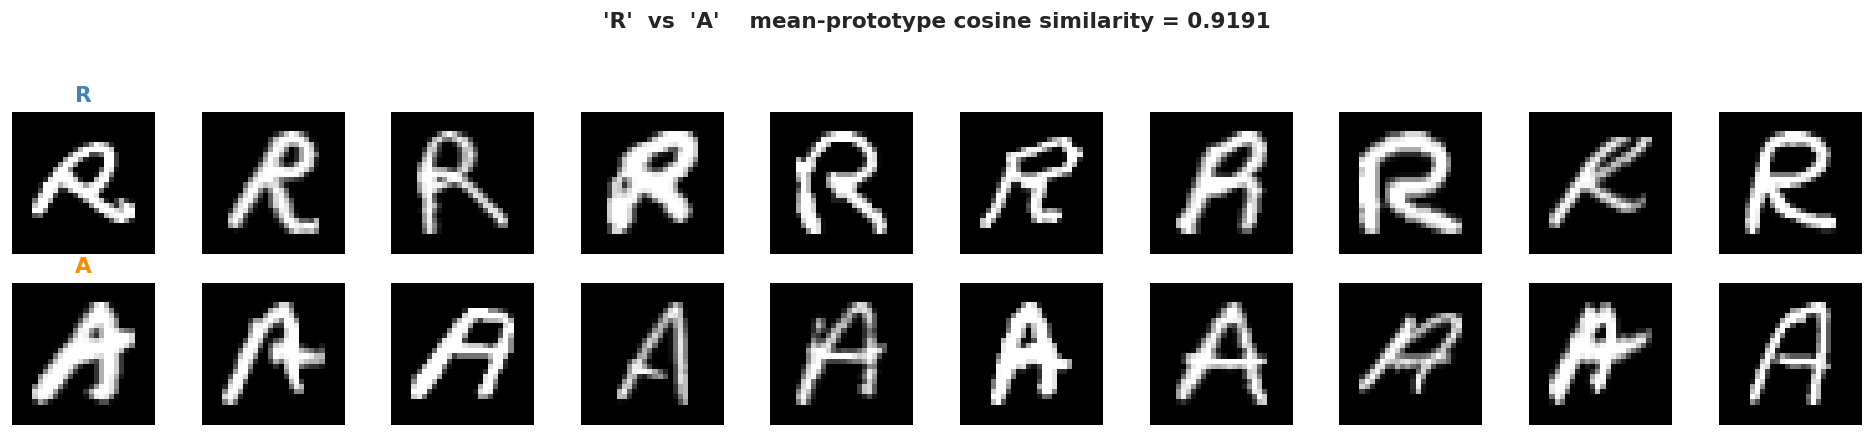

  R <-> A   sim=0.9191   HIGH


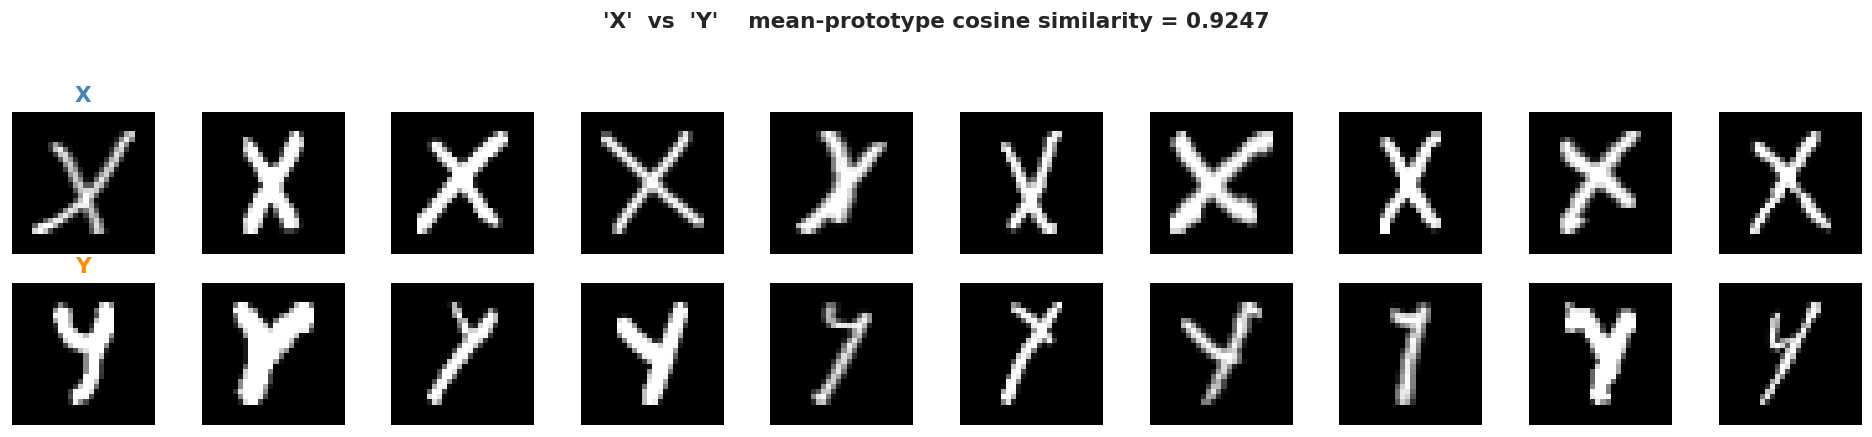

  X <-> Y   sim=0.9247   HIGH


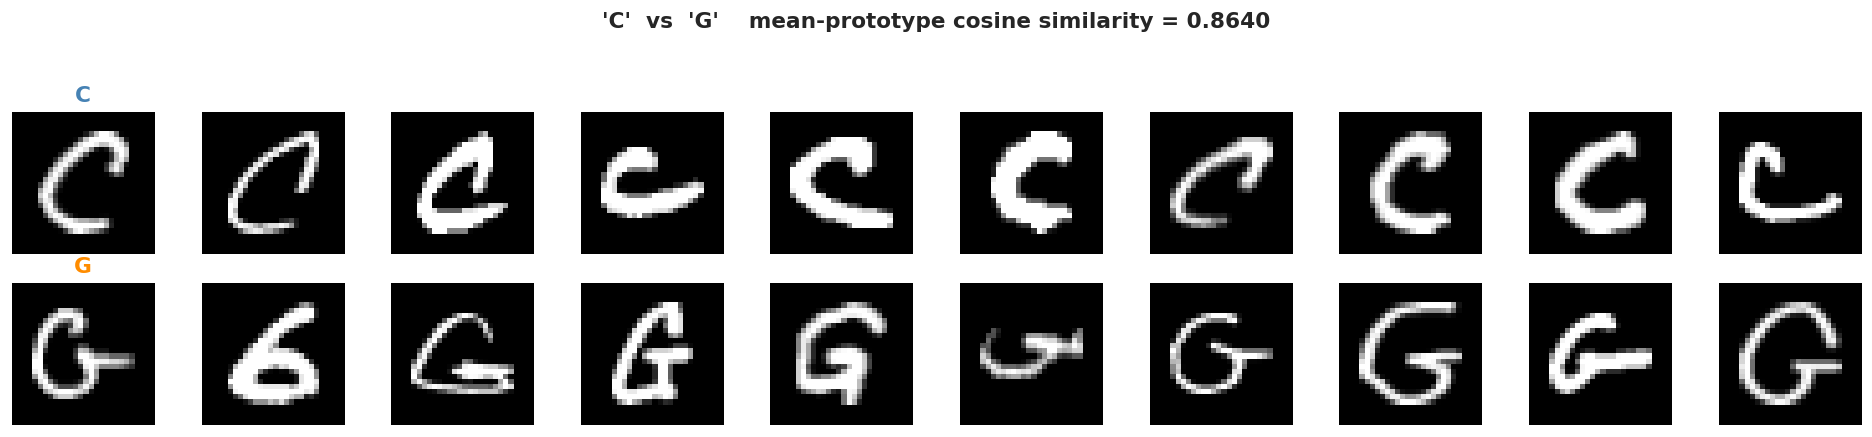

  C <-> G   sim=0.8640   MED


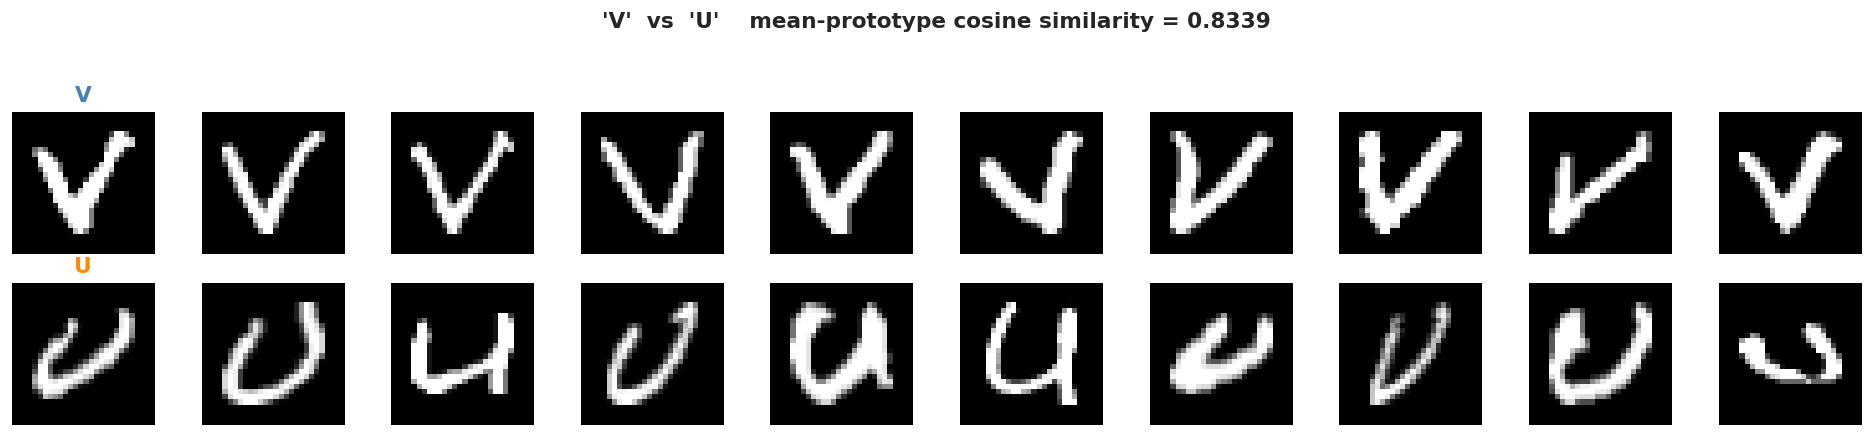

  V <-> U   sim=0.8339   LOW


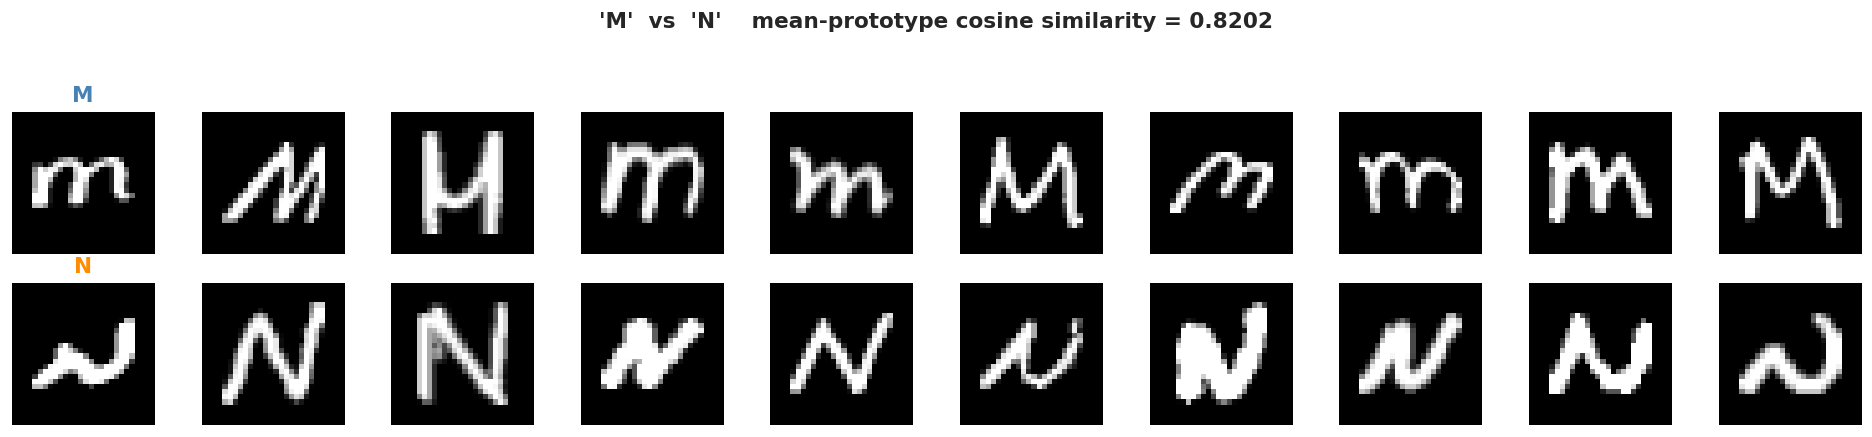

  M <-> N   sim=0.8202   LOW


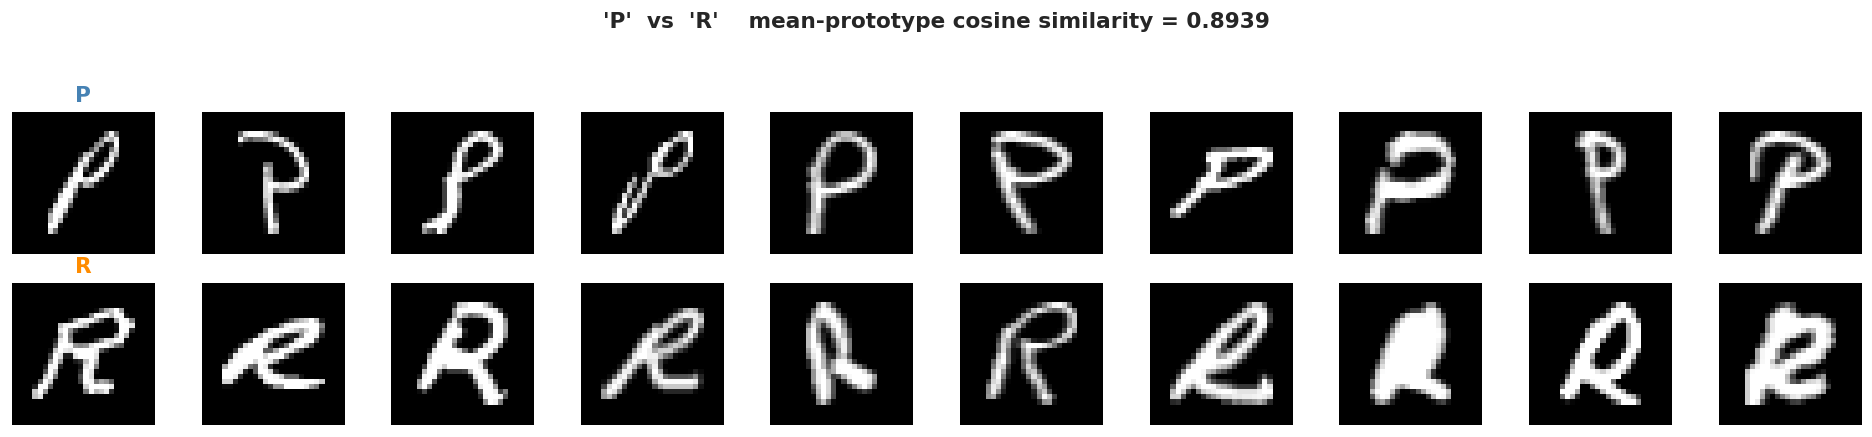

  P <-> R   sim=0.8939   MED


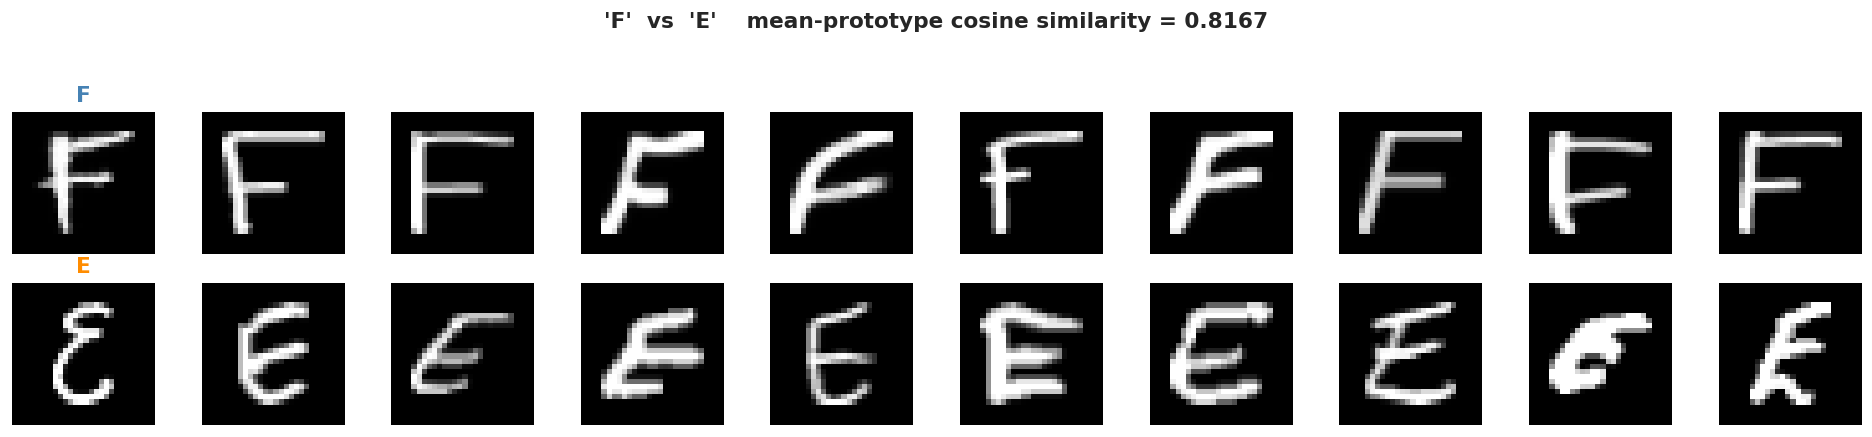

  F <-> E   sim=0.8167   LOW


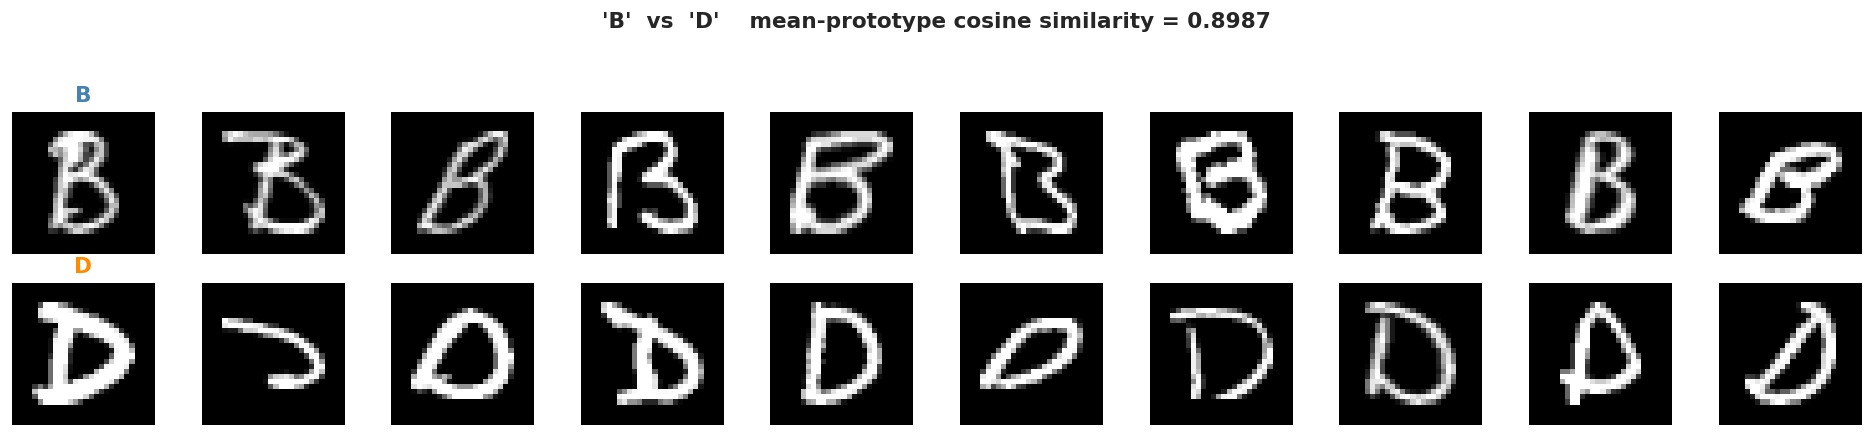

  B <-> D   sim=0.8987   MED


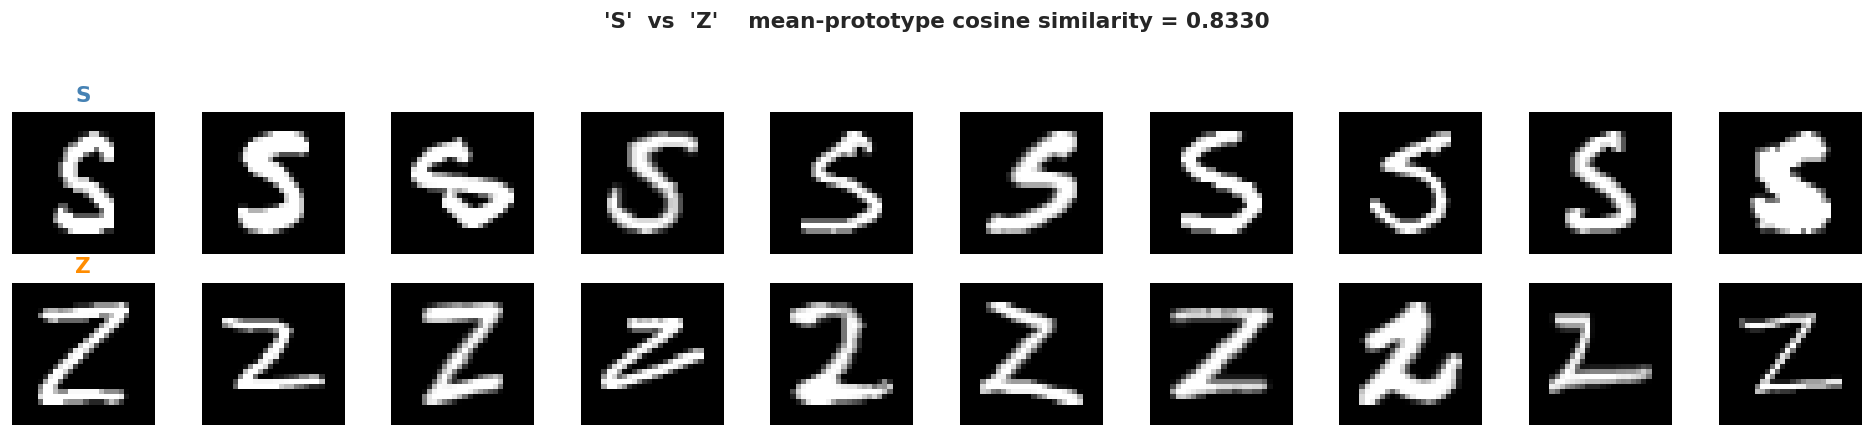

  S <-> Z   sim=0.8330   LOW


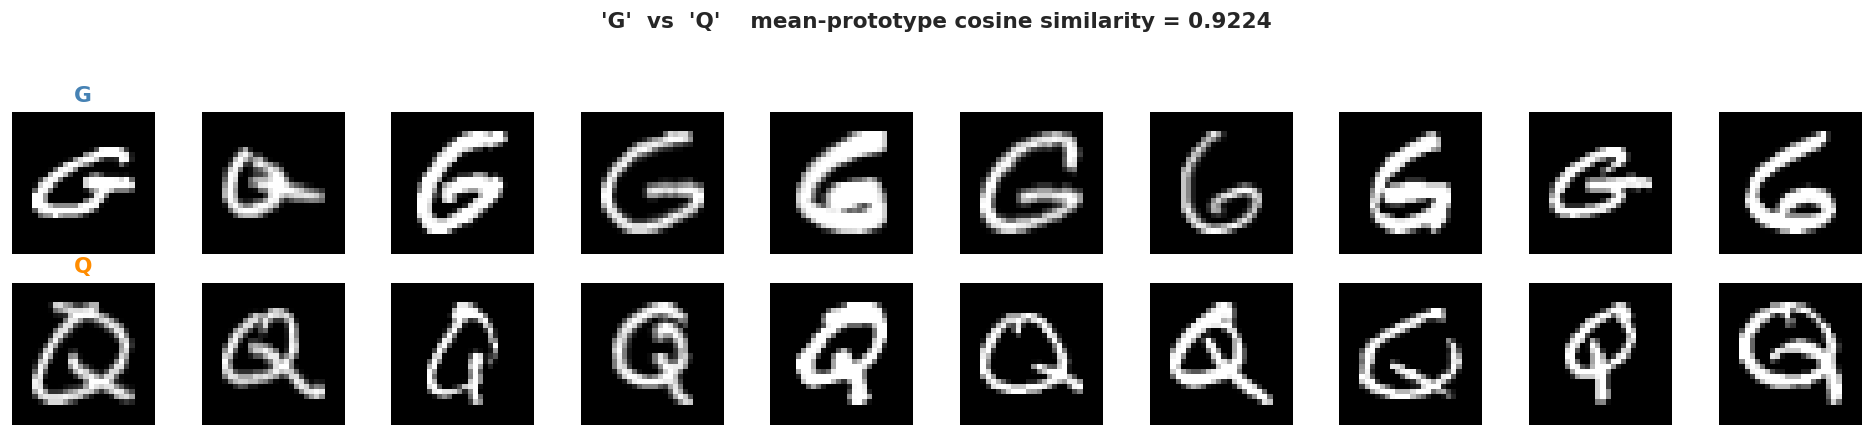

  G <-> Q   sim=0.9224   HIGH


In [57]:
#mean images
mean_imgs = {}
for cls in range(26):
    imgs = images[labels == cls].squeeze()   # all images for this class, shape (N, 28, 28)
    mean_imgs[cls] = imgs.mean(axis=0)     # pixel-wise average = the 'average letter', shape (28, 28)

def cosine_sim(a, b):
    """Cosine similarity between two images treated as flat vectors.
    Score is in [0, 1]: 1.0 = identical direction, 0 = completely orthogonal."""
    a, b = a.flatten(), b.flatten()                                         # flatten 28x28 to 784
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))  # +1e-9 avoids /0

LETTER_TO_IDX = {v: k for k, v in LETTER_MAP.items()}  # reverse map: 'A'->0, 'B'->1, ...

PAIRS = [
    ('A', 'H'),
    ('O', 'D'),
    ('H', 'R'),
    ('K', 'R'),
    ('N','H'),
    ('O', 'Q'),
    ('R','A'),
    ('X','Y'),
    ('C', 'G'),
    ('V', 'U'),
    ('M', 'N'),
    ('P', 'R'),
    ('F', 'E'),
    ('B', 'D'),
    ('S', 'Z'),
    ('G', 'Q')
]

np.random.seed(7)
COLS = 10   # number of sample images shown per letter in each row

for (letA, letB) in PAIRS:
    clsA, clsB = LETTER_TO_IDX[letA], LETTER_TO_IDX[letB]           # convert letters to class indices
    idxA = np.random.choice(np.where(labels == clsA)[0], COLS, replace=False)  # pick 10 samples for A
    idxB = np.random.choice(np.where(labels == clsB)[0], COLS, replace=False)  # pick 10 samples for B
    sim  = cosine_sim(mean_imgs[clsA], mean_imgs[clsB])              # similarity between class means

    fig, axes = plt.subplots(2, COLS, figsize=(16, 3.5))             # 2 rows x 10 columns

    fig.suptitle(
        f"'{letA}'  vs  '{letB}'    mean-prototype cosine similarity = {sim:.4f}",
        fontsize=13, fontweight='bold', y=1.04
    )

    for col in range(COLS):
        axes[0, col].imshow(images[idxA[col]].squeeze(), cmap='gray', vmin=0, vmax=1)  # top row = letter A
        axes[1, col].imshow(images[idxB[col]].squeeze(), cmap='gray', vmin=0, vmax=1)  # bottom row = letter B
        axes[0, col].axis('off'); axes[1, col].axis('off')

        if col == 0:   # label only the first column so the plot stays clean
            axes[0, col].set_title(letA, fontsize=13, fontweight='bold', color='steelblue')
            axes[1, col].set_title(letB, fontsize=13, fontweight='bold', color='darkorange')
        plt.savefig(os.path.join(PLOTS_DIR, f"confusablePair{letA,letB}.png"),
             dpi=300, bbox_inches='tight')

    plt.tight_layout()

    plt.show()

    # Print a quick risk label for each pair
    label = 'HIGH' if sim > 0.91 else ('MED' if sim > 0.85 else 'LOW')
    print(f'  {letA} <-> {letB}   sim={sim:.4f}   {label}')

Most similar pair: G and Q

##Mean Prototype Images

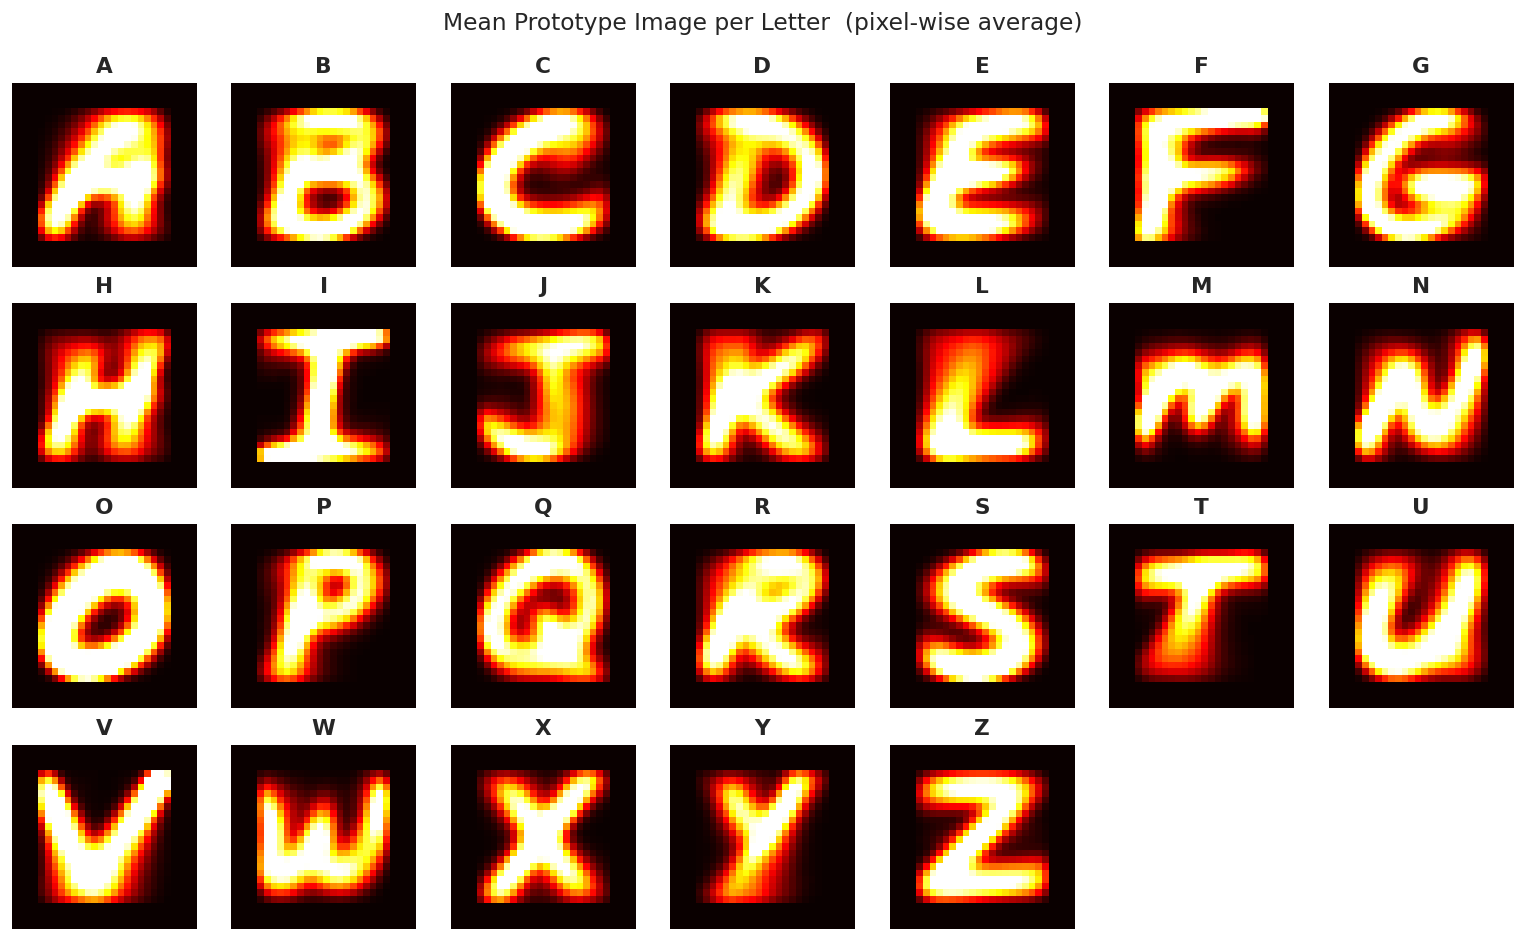

In [33]:
fig, axes = plt.subplots(4, 7, figsize=(13, 8))   # 4 rows x 7 cols = 28 slots; we use 26
fig.suptitle('Mean Prototype Image per Letter  (pixel-wise average)', fontsize=14)

idx = 0
for r in range(4):
    for c in range(7):
        if idx < 26:
            axes[r, c].imshow(mean_imgs[idx], cmap='hot', vmin=0, vmax=0.5)
            axes[r, c].set_title(LETTER_MAP[idx])
            axes[r, c].axis('off')
            idx += 1
        else:
            axes[r, c].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "meanPrototypes.png"),
                dpi=300, bbox_inches='tight')
plt.show()

- **Sharp, bright prototypes** (e.g. O, Z, I,X) indicate that most writers draw those letters in roughly the same way .
- **Blurry or dim prototypes** (e.g. Y, P, J,R) indicate high variation: strokes appear in different positions across writers, so the average washes out. These classes will be harder for a model to learn a clean decision boundary for.
- The prototype also visually confirms the **structural skeleton** of each letter, which is what a convolutional model is ultimately trying to detect.

##Brightness & Contrast per Class

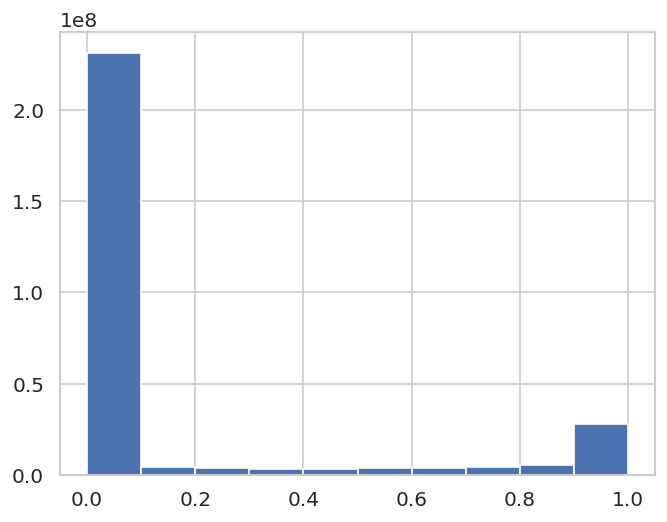

In [24]:
plt.hist(images.flatten())
plt.show()

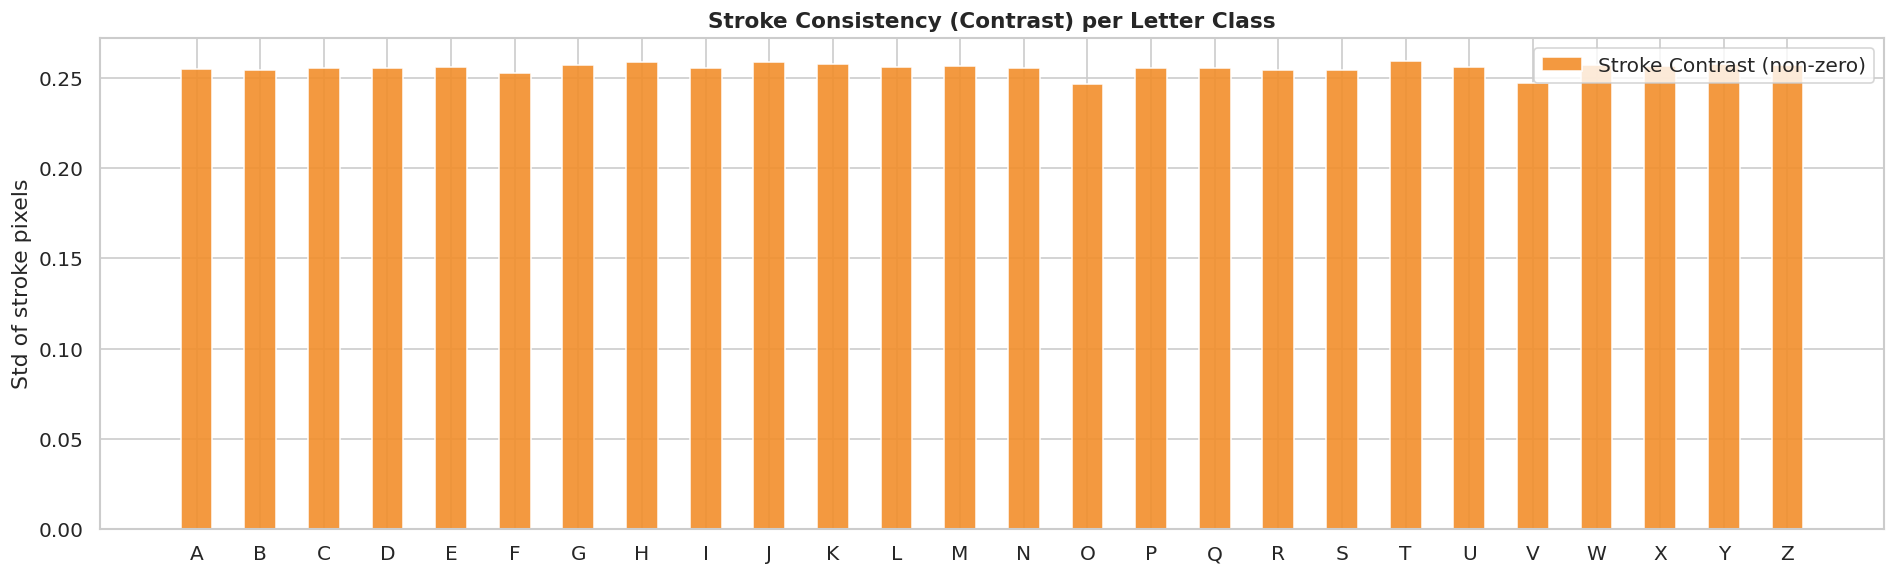

Most variable strokes   : T (0.2593)
Most consistent strokes : O (0.2463)


In [34]:
contrast = []   # one value per class

for cls in range(26):
    imgs = images[labels == cls].squeeze().reshape(-1, 784)
    threshold = 0.2
    non_zero_pixels = imgs[imgs > threshold]

    if len(non_zero_pixels) > 0:
        contrast.append(non_zero_pixels.std())
    else:
        contrast.append(0.0)

# Plot
x = np.arange(26)
w = 0.5   # now we only have ONE bar per letter, so we can make it wider

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, contrast, w,
       label='Stroke Contrast (non-zero)',
       color='#f28e2b', alpha=0.9, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(letters)
ax.set_ylabel('Std of stroke pixels')
ax.set_title('Stroke Consistency (Contrast) per Letter Class')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "contrastPerLetterClass.png"),
                dpi=300, bbox_inches='tight')
plt.show()

# Extremes
high_idx = np.argmax(contrast)
low_idx  = np.argmin(contrast)

print(f'Most variable strokes   : {letters[high_idx]} ({contrast[high_idx]:.4f})')
print(f'Most consistent strokes : {letters[low_idx]} ({contrast[low_idx]:.4f})')

- Letters with low contrast tend to have smooth, consistent strokes, making them easier for a model to learn.  
- In contrast, letters with high contrast show greater variation in stroke intensity and shape, indicating inconsistent handwriting and increased classification difficulty.
- These statistics won't be fed directly to the model, but they explain **why some classes are easier** — consistent stroke density makes the signal cleaner for the classifier.
- For the most part,our data is similar in contrast levels.

In [65]:
std_imgs = {}

for cls in range(26):
    imgs = images[labels == cls].squeeze()   #shape: (N, 28, 28), N is the num of samples

    std_imgs[cls] = imgs.std(axis=0)         #pixel-wise std (28, 28) (std of that pixel across all samples)


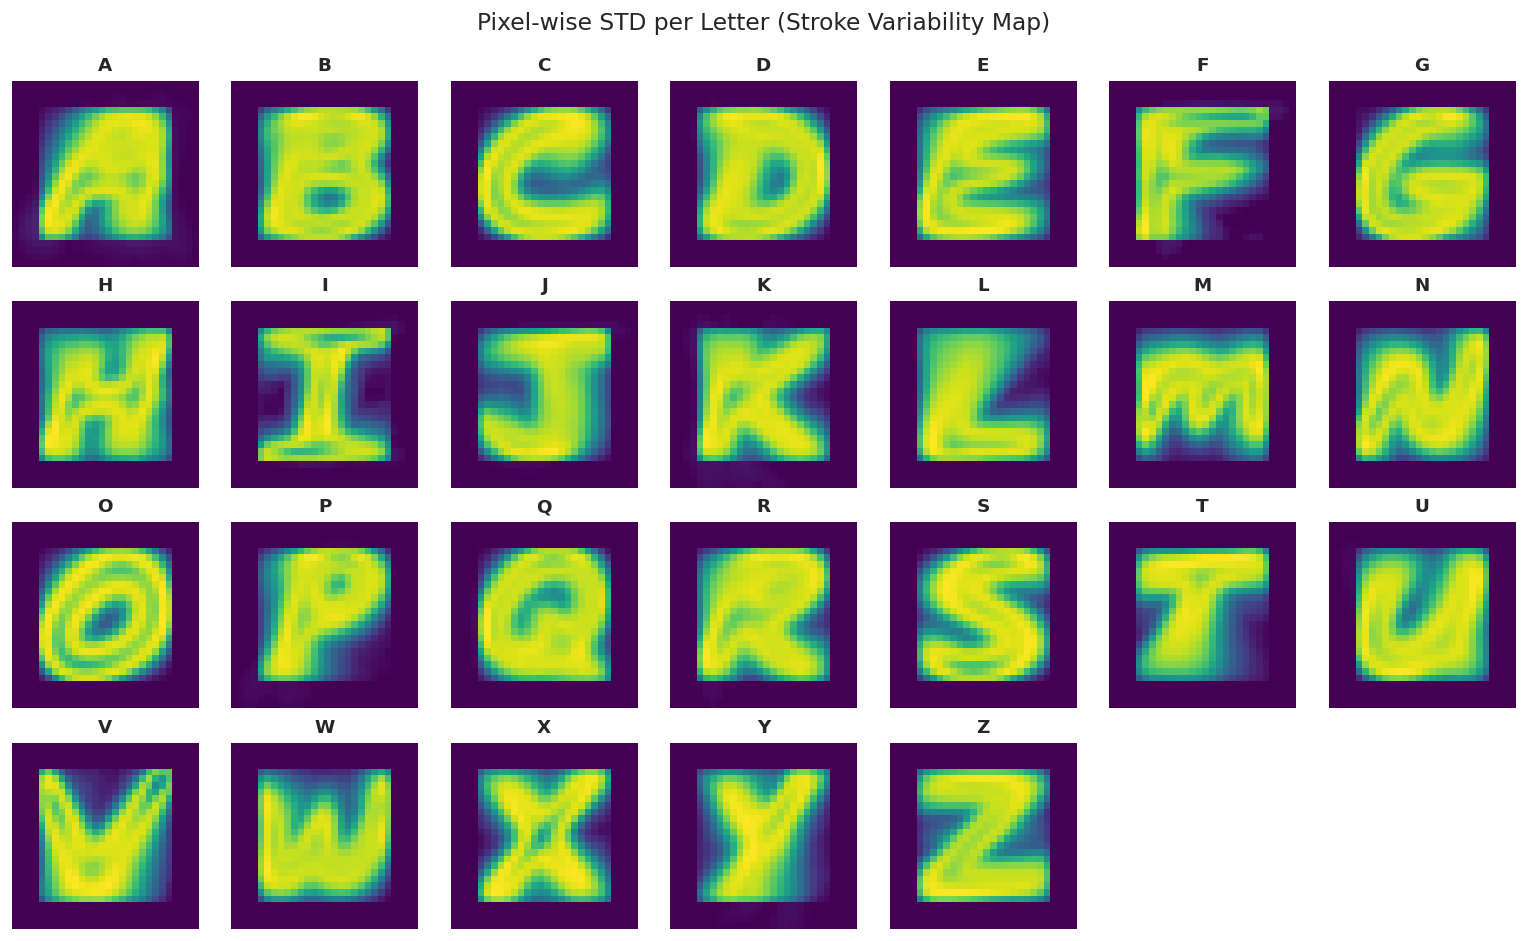

In [64]:
fig, axes = plt.subplots(4, 7, figsize=(13, 8))
fig.suptitle('Pixel-wise STD per Letter (Stroke Variability Map)', fontsize=14)

for cls in range(26):
    r, c = divmod(cls, 7)

    axes[r, c].imshow(std_imgs[cls],
                      cmap='viridis')

    axes[r, c].set_title(letters[cls], fontsize=11)
    axes[r, c].axis('off')

# hide empty slots
for extra in range(26, 28):
    axes.flatten()[extra].axis('off') #hiding the empty subplot labels ticks grid etc

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "strokeVariabilityMaps.png"),
                dpi=300, bbox_inches='tight')
plt.show()

- dark = low variation
- bright = high variation

##Edge Density per Class

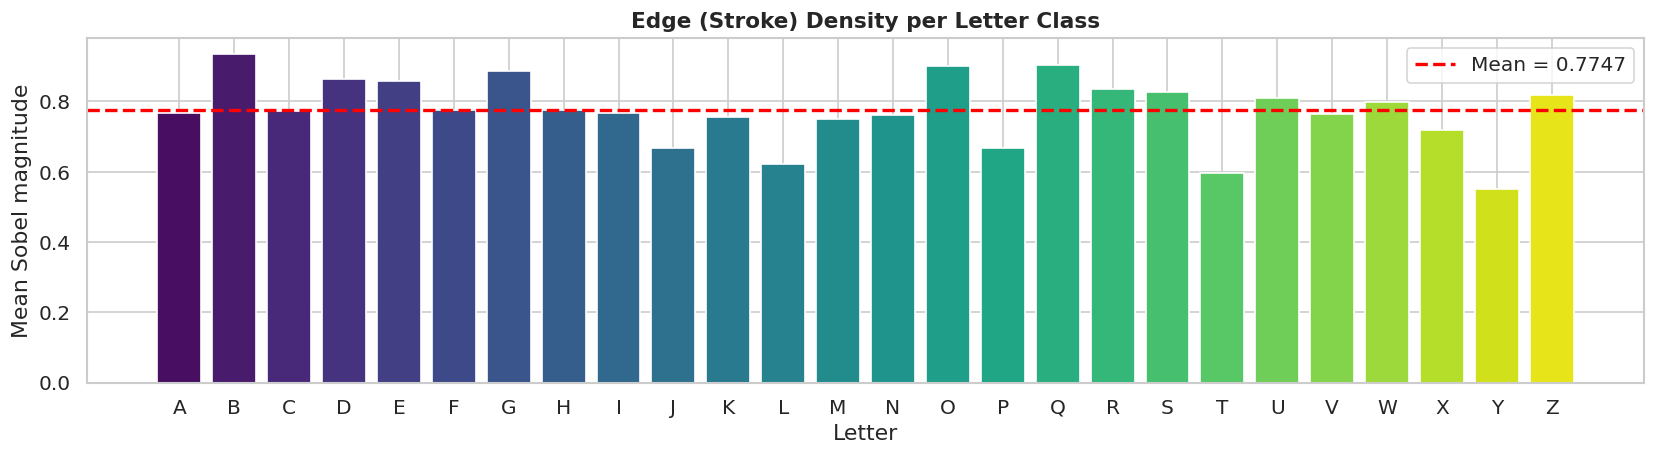

Most  complex strokes: B  (0.9349)
Least complex strokes: Y  (0.5519)


In [39]:
#Sobel filter kernels
# A large gradient = a sharp edge (transition from dark to bright or vice versa).
SOBEL_X = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)   # detects vertical edges (left-right changes)

SOBEL_Y = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]], dtype=np.float32)  # detects horizontal edges (top-bottom changes)

def sobel_density(img):
    #Return the mean edge magnitude for a single 28x28 image.
    #Higher value = more edges = more stroke complexity
    gx = convolve2d(img, SOBEL_X, mode='same', boundary='symm')   # horizontal gradient
    gy = convolve2d(img, SOBEL_Y, mode='same', boundary='symm')   # vertical gradient
    return np.sqrt(gx**2 + gy**2).mean() # gradient magnitude, then average

np.random.seed(1)
edge_dens = []
for cls in range(26):
    idx  = np.where(labels == cls)[0]
    pick = np.random.choice(idx, min(5000, len(idx)), replace=False)
    edge_dens.append(
        np.mean([sobel_density(images[i].squeeze()) for i in pick])   # average edge density for this class
    )

fig, ax = plt.subplots(figsize=(14, 4))
colours = sns.color_palette('viridis', 26)  # one distinct colour per letter
ax.bar(letters, edge_dens, color=colours, edgecolor='white')
ax.axhline(np.mean(edge_dens), color='red', lw=2, ls='--',
           label=f"Mean = {np.mean(edge_dens):.4f}") # dashed mean reference line
ax.set_xlabel('Letter'); ax.set_ylabel('Mean Sobel magnitude')
ax.set_title('Edge (Stroke) Density per Letter Class')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "edgeDensityPerLetterClass.png"),
                dpi=300, bbox_inches='tight')
plt.show()

earr = np.array(edge_dens)
print(f'Most  complex strokes: {letters[earr.argmax()]}  ({earr.max():.4f})')
print(f'Least complex strokes: {letters[earr.argmin()]}  ({earr.min():.4f})')

**Edge density** measures **stroke complexity** — how many pixel-level transitions (dark→bright) exist on average per image.

##Inter-Class Cosine Similarity Heat-Map

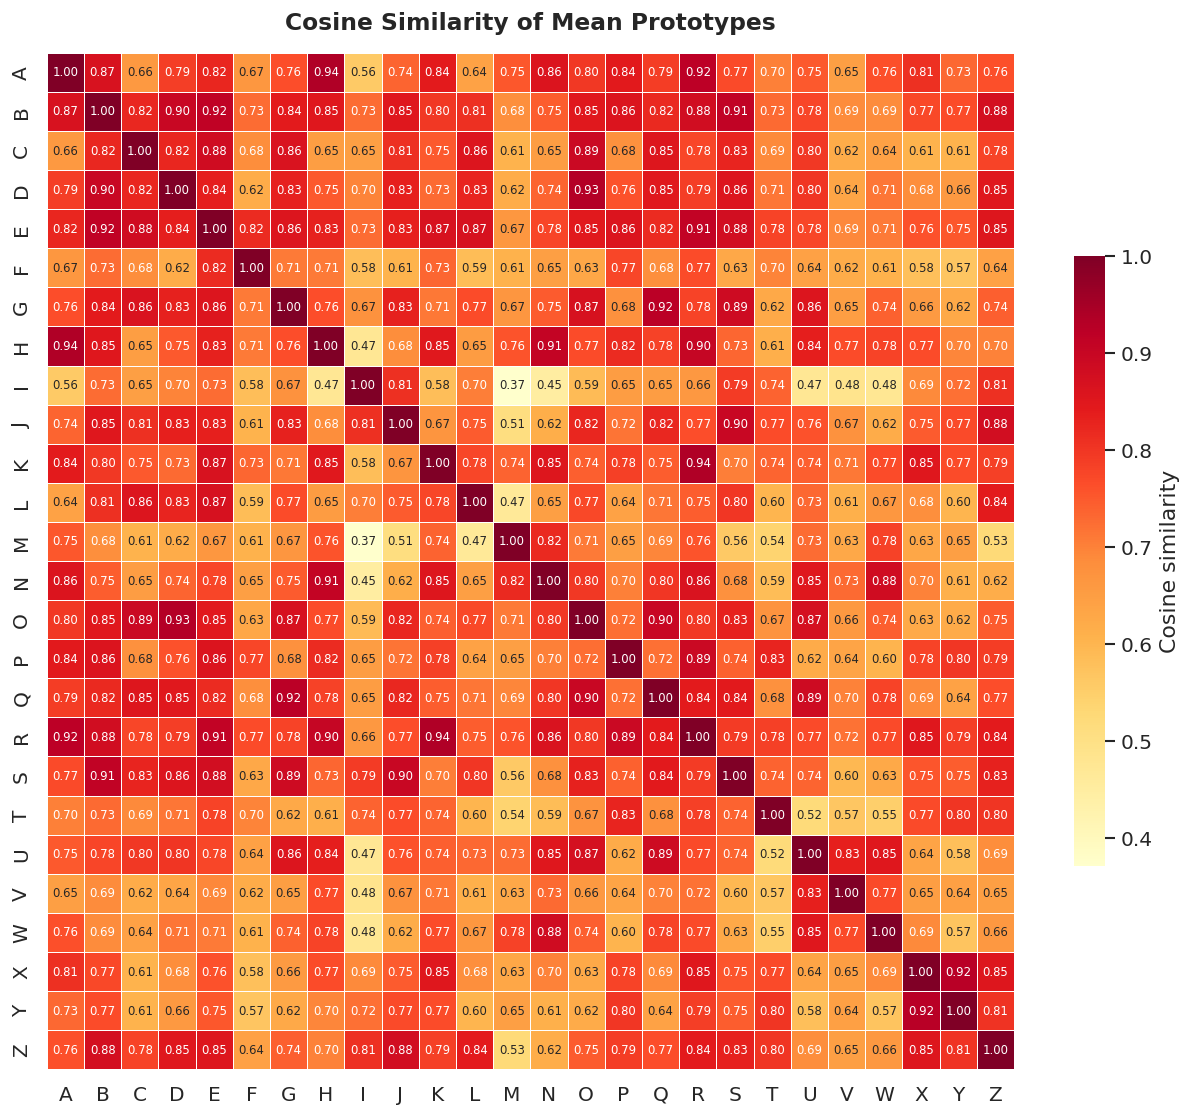

Most confusable pair: A <-> H  (sim=0.9384)


In [50]:
#  Stack all 26 mean prototype images into one matrix
M = np.stack([mean_imgs[c].flatten() for c in range(26)])  # shape (26, 784)

# Normalise each row to unit length — then dot product equals cosine similarity
M_norm = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)

sim_mat = M_norm @ M_norm.T   # (26, 784) x (784, 26) -> (26, 26) , @ is matrix multiplication

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.eye(26, dtype=bool)   # mask the diagonal (self-similarity = 1.0, always, so not informative)

sns.heatmap(sim_mat, ax=ax,
            xticklabels=letters, yticklabels=letters,
            cmap='YlOrRd',                  # yellow=low similarity, red=high similarity
            annot=True, fmt='.2f',          # print the numeric value inside each cell
            linewidths=0.3,                 # thin grid lines between cells
            annot_kws={'size': 7},
            cbar_kws={'label': 'Cosine similarity', 'shrink': 0.6})

ax.set_title('Cosine Similarity of Mean Prototypes', fontsize=14, pad=14)
plt.savefig(os.path.join(PLOTS_DIR, "cosineSimilarityHeatmap.png"),
                dpi=300, bbox_inches='tight')
plt.show()

# Find the single most confusable pair
tmp = sim_mat.copy()
np.fill_diagonal(tmp, 0)                           #zero the diagonal so argmax finds an off-diagonal entry
r, c = np.unravel_index(tmp.argmax(), tmp.shape)   #unraveling based on shape
print(f'Most confusable pair: {letters[r]} <-> {letters[c]}  (sim={sim_mat[r,c]:.4f})')

This 26×26 heat-map provides a **global view of all pairwise confusions** simultaneously,something impossible to see from pair-by-pair plots alone.

##Intra-Class Variation Maps

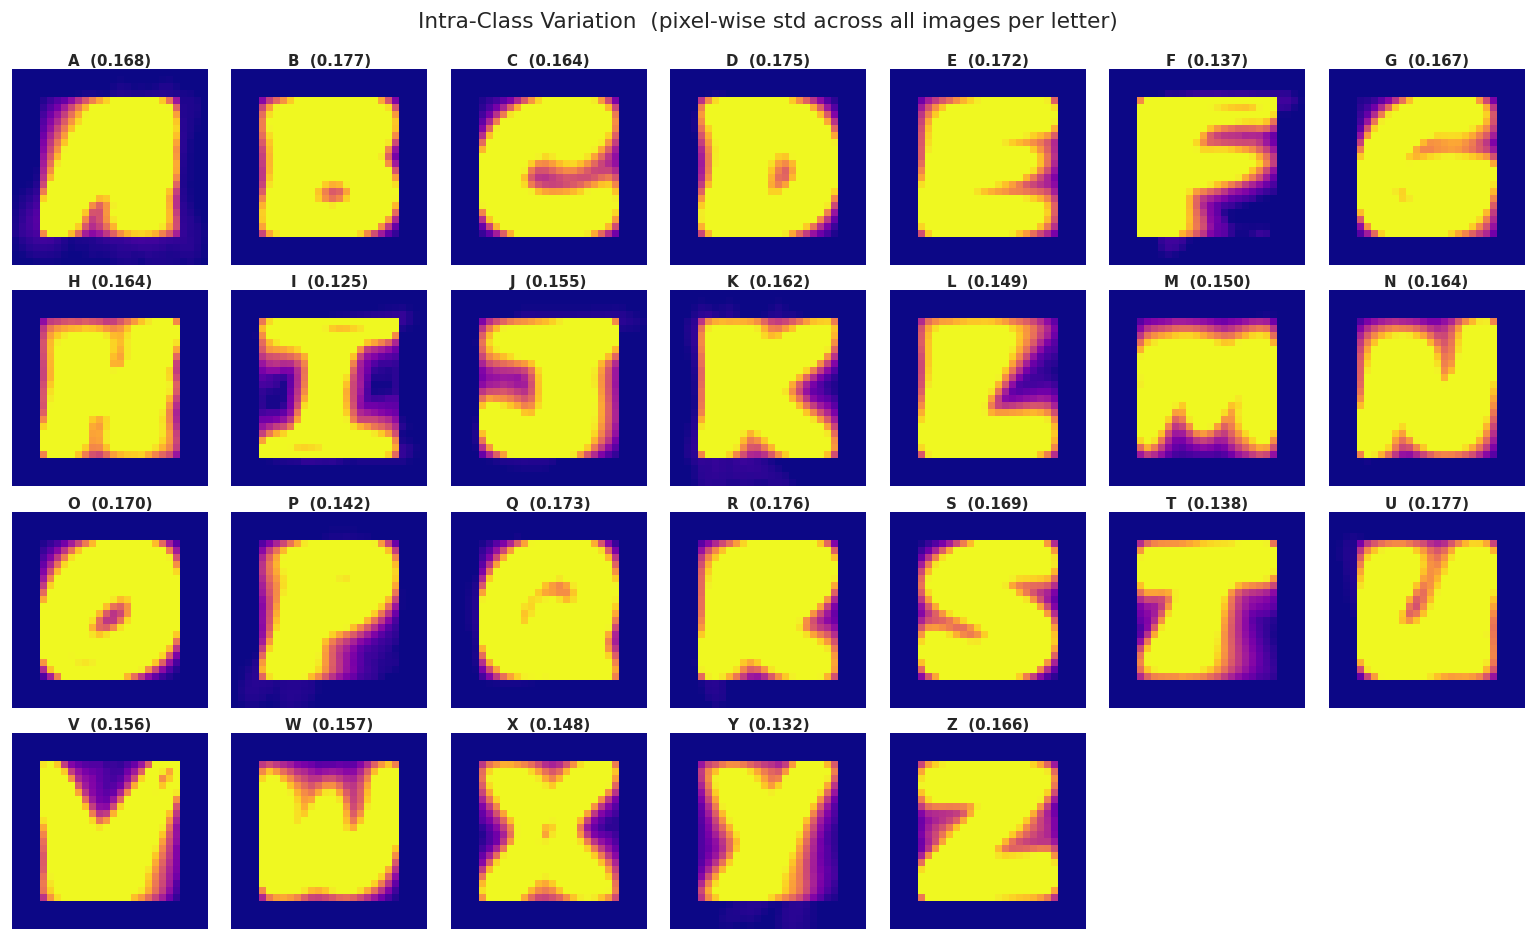

Most varied  class: U  (avg std=0.1774) -> hardest to generalise
Least varied class: I  (avg std=0.1250) -> most consistent writers


In [58]:
fig, axes = plt.subplots(4, 7, figsize=(13, 8))   # same 4x7 grid layout as Plot 5
fig.suptitle(
    'Intra-Class Variation  (pixel-wise std across all images per letter)',
    fontsize=13
)

variation_score = []   # will store the mean std for each class as a single number

for cls in range(26):
    r, c    = divmod(cls, 7)
    imgs    = images[labels == cls].squeeze()  # all images for this class, shape (N, 28, 28)
    std_map = imgs.std(axis=0)               # pixel-wise std across all N images -> shape (28, 28)
    # A bright pixel in std_map = writers disagree on whether that pixel is inked.
    # A dark pixel = everyone consistently agrees (always background or always a stroke there).
    variation_score.append(std_map.mean())   # single-number summary: average disagreement per pixel

    axes[r, c].imshow(std_map, cmap='plasma',   # plasma: dark purple=low, bright yellow=high variation
                      vmin=0, vmax=0.3)
    axes[r, c].set_title(f"{LETTER_MAP[cls]}  ({std_map.mean():.3f})", fontsize=9, pad=2)
    axes[r, c].axis('off')

for extra in range(26 % 7, 7):                   # hide unused cells in the last row
    axes[3, extra].set_visible(False)

plt.tight_layout()
plt.show()

va = np.array(variation_score)
print(f'Most varied  class: {letters[va.argmax()]}  (avg std={va.max():.4f}) -> hardest to generalise')
print(f'Least varied class: {letters[va.argmin()]}  (avg std={va.min():.4f}) -> most consistent writers')